# Trabajo Final – Inteligencia Artificial 2026-I

**Universidad del Magdalena**  
**Tema:** Reconocimiento de Lenguaje de Señas Americano (ASL) mediante Aprendizaje Supervisado  

**Integrantes:**  
- David José Mejía Mejía  
- Juan Pablo Bolaño Mejía  
- Rigoberto Varrilla Gutiérrez  

**Fecha:** 22 de mayo de 2026

---

## Objetivo general

Desarrollar y evaluar modelos de aprendizaje supervisado para el reconocimiento de letras del Lenguaje de Señas Americano (ASL) a partir de imágenes, aplicando técnicas de preprocesamiento, reducción de dimensionalidad, ajuste de hiperparámetros y comparación de métricas, con el fin de identificar el modelo con mejor desempeño para la clasificación automática de las señas del alfabeto.

## I. Descripción del problema e inspección del conjunto de datos

### 1. Descripción del problema de clasificación

El proyecto aborda un problema de **clasificación supervisada de imágenes** aplicado al reconocimiento de señas manuales del alfabeto del lenguaje de señas americano (**ASL, American Sign Language**). Cada observación corresponde a una imagen de una mano realizando una seña y la tarea del modelo consiste en asignar dicha imagen a una de las clases disponibles.

En el conjunto de datos usado en este notebook, la **variable objetivo** es la letra representada en la imagen (`A` a `Z`). Las **variables de entrada** son los valores de los píxeles de cada imagen. Inicialmente las imágenes se encuentran en archivos `.jpg`; durante el preprocesamiento se elimina el borde magenta, se redimensionan a un tamaño común de **128 x 128 píxeles**, se convierten a escala de grises y se normalizan al rango `[0, 1]` para los modelos clásicos. Para el modelo profundo VGG16 se trabaja con imágenes RGB redimensionadas a **128 x 128 píxeles**.

El dataset local está organizado en carpetas por clase dentro de `data/train` y en imágenes independientes dentro de `data/test`. En este estado del proyecto se cuenta con **26 clases**, **4.680 imágenes de entrenamiento** y **520 imágenes de prueba**, para un total de **5.200 imágenes**. Las clases están balanceadas: cada letra tiene **200 imágenes en total**, distribuidas en 180 imágenes de entrenamiento y 20 imágenes de prueba.

Esta tarea es relevante porque permite automatizar el reconocimiento visual de gestos estáticos del alfabeto ASL. Aunque el problema se trabaja en condiciones controladas, sirve como base para sistemas de apoyo a la comunicación, interfaces inclusivas y aplicaciones educativas relacionadas con lenguaje de señas.


In [101]:
# Librerias para inspeccion, visualizacion y conexion con el codigo del proyecto
%matplotlib inline
# Ocultar advertencias para mantener limpio el notebook
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import inspect
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# Detectar la raíz del proyecto para poder importar los módulos de src/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT / "aprendizaje_supervisado" / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT / "aprendizaje_supervisado"

os.chdir(PROJECT_ROOT)
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from preprocessing import (
    IMG_SIZE,
    VALID_LABELS,
    remove_magenta_border,
    remove_dark_frame,
    clear_outer_edges,
    pad_to_square,
    resize_to_fixed_size,
    process_single_image,
    load_dataset,
    load_test_dataset,
)
from feature_engineering import (
    vectorize_images,
    remove_quasi_constant_features,
    apply_pca,
)

sns.set_theme(style="whitegrid")
print(f"Raíz del proyecto: {PROJECT_ROOT}")
print("Librerías y módulos del proyecto cargados correctamente.")


Raíz del proyecto: c:\Users\Adal\Downloads\aprendizaje_supervisado (3)\aprendizaje_supervisado
Librerías y módulos del proyecto cargados correctamente.


*Importa las librerias necesarias para analisis, visualizacion y acceso a los modulos del proyecto; ademas configura el path del entorno para encontrar el codigo fuente.*

### 2. Carga e inspección inicial

En esta parte se cargan los arreglos preprocesados generados por `src/preprocessing.py`. Estos archivos contienen las imágenes ya normalizadas, sin borde magenta y con tamaño uniforme. También se inspecciona la estructura de carpetas original para verificar el número de clases y la cantidad de imágenes disponibles por clase.


## Librerías utilizadas en el proyecto

| Librería | Descripción |
|---|---|
| `numpy` | Se utiliza para manejar arreglos numéricos, transformar datos y guardar archivos `.npy`. |
| `os` | Permite trabajar con rutas, carpetas y archivos del sistema. |
| `gc` | Se usa para liberar memoria durante el procesamiento de imágenes. |
| `time` | Permite medir el tiempo de entrenamiento y búsqueda de hiperparámetros. |
| `joblib` | Se utiliza para guardar y cargar modelos entrenados y transformadores como PCA. |
| `cv2` | Librería OpenCV usada para leer, limpiar, redimensionar y procesar imágenes. |
| `matplotlib.pyplot` | Se usa para generar gráficos y visualizaciones. |
| `seaborn` | Permite crear gráficos estadísticos y mapas de calor más claros. |
| `train_test_split` | Divide el dataset en entrenamiento, validación y prueba. |
| `GridSearchCV` | Prueba diferentes combinaciones de hiperparámetros usando validación cruzada. |
| `PCA` | Reduce la dimensionalidad de los datos conservando la mayor información posible. |
| `VarianceThreshold` | Elimina características con poca variabilidad. |
| `LogisticRegression` | Modelo de clasificación usado como regresión logística multinomial. |
| `DecisionTreeClassifier` | Modelo basado en árboles de decisión. |
| `RandomForestClassifier` | Modelo de ensamble basado en varios árboles de decisión. |
| `MLPClassifier` | Red neuronal multicapa usada para clasificación. |
| `accuracy_score` | Calcula la exactitud general del modelo. |
| `precision_score` | Calcula la precisión de las predicciones. |
| `recall_score` | Calcula la capacidad del modelo para detectar correctamente las clases. |
| `f1_score` | Combina precision y recall en una sola métrica. |
| `confusion_matrix` | Genera la matriz de confusión. |
| `classification_report` | Genera un reporte con precision, recall, F1-score y support. |
| `tensorflow` | Se usa para construir y entrenar modelos de deep learning. |
| `keras.layers` | Permite crear capas de redes neuronales. |
| `keras.models` | Permite construir modelos de redes neuronales. |
| `VGG16` | Arquitectura preentrenada usada para transferencia de aprendizaje. |
| `ResNet50` | Arquitectura profunda usada para clasificación mediante transferencia de aprendizaje. |
| `MobileNetV2` | Modelo preentrenado liviano usado para deep learning. |

## Variables principales utilizadas en el proyecto

| Variable | Descripción |
|---|---|
| `IMG_SIZE` | Define el tamaño estándar de las imágenes. En el proyecto se usa `(128, 128)` para que todas las imágenes tengan la misma dimensión. |
| `X` | Contiene todas las imágenes procesadas del dataset antes de dividirlas. |
| `y` | Contiene las etiquetas de cada imagen, es decir, las letras del alfabeto ASL. |
| `X_train` | Conjunto de imágenes usado para entrenar los modelos. |
| `y_train` | Etiquetas reales del conjunto de entrenamiento. |
| `X_val` | Conjunto de validación usado para evaluar el modelo durante el ajuste. |
| `y_val` | Etiquetas reales del conjunto de validación. |
| `X_test` | Conjunto de prueba usado para evaluar el rendimiento final del modelo. |
| `y_test` | Etiquetas reales del conjunto de prueba. |
| `X_train_flat` | Imágenes de entrenamiento convertidas de matriz 2D a vector 1D. |
| `X_val_flat` | Imágenes de validación vectorizadas. |
| `X_test_flat` | Imágenes de prueba vectorizadas. |
| `selector` | Objeto usado para eliminar características cuasi-constantes mediante `VarianceThreshold`. |
| `X_train_filtered` | Datos de entrenamiento después de eliminar características con poca variabilidad. |
| `X_val_filtered` | Datos de validación después del filtro de varianza. |
| `X_test_filtered` | Datos de prueba después del filtro de varianza. |
| `pca` | Objeto usado para reducir la dimensionalidad de los datos mediante PCA. |
| `X_train_pca` | Datos de entrenamiento transformados con PCA. |
| `X_val_pca` | Datos de validación transformados con PCA. |
| `X_test_pca` | Datos de prueba transformados con PCA. |
| `N_COMPONENTS` | Define la cantidad de componentes principales usados en PCA. |
| `models` | Diccionario donde se almacenan los modelos utilizados. |
| `param_grids` | Diccionario con los hiperparámetros que se prueban con `GridSearchCV`. |
| `grid` | Objeto de `GridSearchCV` usado para buscar la mejor configuración de cada modelo. |
| `best_model` | Guarda el mejor modelo obtenido después de la comparación. |
| `best_model_name` | Guarda el nombre del modelo con mejor desempeño. |
| `results` | Diccionario donde se almacenan los resultados de los modelos. |
| `y_pred` | Contiene las predicciones realizadas por el modelo. |
| `conf_matrix` | Matriz de confusión usada para analizar aciertos y errores por clase. |
| `class_report` | Reporte de clasificación con precision, recall, F1-score y support. |

In [102]:
# Rutas principales del proyecto
train_dir = "data/train"
test_dir = "data/test"

X_train_path = "data/processed/X_train.npy"
y_train_path = "data/processed/y_train.npy"
X_test_path = "data/processed/X_test.npy"
y_test_path = "data/processed/y_test.npy"

# Cargar datos preprocesados
if all(os.path.exists(p) for p in [X_train_path, y_train_path, X_test_path, y_test_path]):
    X_train = np.load(X_train_path)
    y_train = np.load(y_train_path)
    X_test = np.load(X_test_path)
    y_test = np.load(y_test_path)
else:
    raise FileNotFoundError("Faltan archivos en data/processed/. Ejecuta primero src/preprocessing.py")

# Conteo de imágenes por clase desde las carpetas originales
train_counts = {}
for label in sorted(os.listdir(train_dir)):
    folder = os.path.join(train_dir, label)
    if os.path.isdir(folder):
        train_counts[label] = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

test_counts = Counter([
    name.split("_")[0]
    for name in os.listdir(test_dir)
    if name.lower().endswith((".jpg", ".jpeg", ".png"))
])

summary = pd.DataFrame({
    "Métrica": [
        "Clases",
        "Imágenes de entrenamiento",
        "Imágenes de prueba",
        "Tamaño de X_train",
        "Tamaño de X_test",
        "Rango de píxeles procesados"
    ],
    "Valor": [
        len(train_counts),
        int(sum(train_counts.values())),
        int(sum(test_counts.values())),
        str(X_train.shape),
        str(X_test.shape),
        f"{X_train.min():.2f} a {X_train.max():.2f}"
    ]
})

summary


,Métrica,Valor
0,Clases,26
1,Imágenes de entrenamiento,4680
2,Imágenes de prueba,520
3,Tamaño de X_train,"(4680, 128, 128)"
4,Tamaño de X_test,"(520, 128, 128)"
5,Rango de píxeles procesados,0.17 a 1.00


*Define las rutas de los datos y carga los arreglos preprocesados (X_train, y_train, X_test, y_test) desde archivos .npy; si no existen, los genera ejecutando el preprocesamiento.*

In [103]:
# Tabla de distribucion por clase
class_distribution = pd.DataFrame({
    "Clase": sorted(train_counts.keys()),
    "Entrenamiento": [train_counts[c] for c in sorted(train_counts.keys())],
    "Prueba": [test_counts.get(c, 0) for c in sorted(train_counts.keys())],
})

class_distribution["Total"] = (
    class_distribution["Entrenamiento"] + class_distribution["Prueba"]
)

class_distribution


,Clase,Entrenamiento,Prueba,Total
0,A,180,20,200
1,B,180,20,200
2,C,180,20,200
3,D,180,20,200
4,E,180,20,200
5,F,180,20,200
6,G,180,20,200
7,H,180,20,200
8,I,180,20,200
9,J,180,20,200


*Construye y muestra una tabla que resume cuantas imagenes hay por clase en los conjuntos de entrenamiento y prueba, mas un total acumulado.*

### Resultado: distribución de clases

![Distribución de clases](reports/distribucion_clases.png)

La tabla anterior confirma que el conjunto usado en el proyecto contiene 26 clases correspondientes a las letras `A-Z`. La cantidad de imágenes por clase es uniforme, lo cual reduce el riesgo de que el modelo favorezca una clase mayoritaria durante el entrenamiento.


### Preprocesamiento aplicado a las imagenes

Antes de entrenar los modelos, cada imagen del dataset pasa por una etapa de preprocesamiento definida en `src/preprocessing.py`. El objetivo es que todas las observaciones tengan el mismo formato numerico y puedan compararse correctamente en los algoritmos clasicos.

A continuacion se muestra cada paso junto con el codigo utilizado.


#### Paso 0. Configuracion general

Se define el tamano final de las imagenes y las etiquetas validas del dataset ASL.


##### Código usado: configuración base

Este bloque muestra los parámetros globales del preprocesamiento definidos en el proyecto: tamaño final de imagen y etiquetas válidas.


In [104]:
# Configuracion real importada desde src/preprocessing.py
print(f"Tamano final de imagen: {IMG_SIZE}")
print(f"Cantidad de etiquetas validas definidas: {len(VALID_LABELS)}")
print(f"Etiquetas presentes en este dataset: {sorted(train_counts.keys())}")


Tamano final de imagen: (128, 128)
Cantidad de etiquetas validas definidas: 29
Etiquetas presentes en este dataset: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


*Imprime los parametros globales de preprocesamiento: tamano de imagen (IMG_SIZE) y la lista de etiquetas validas definidas en el modulo de preprocesamiento.*

#### Paso 1. Carga de la imagen

Cada archivo `.jpg`, `.jpeg` o `.png` se lee con OpenCV mediante `cv2.imread`. Si OpenCV no puede leer la imagen, se descarta.


##### Código usado: lectura de imagen

Aquí se muestra la parte del código real donde la imagen se carga desde disco con OpenCV. Esta lectura es el punto de entrada del preprocesamiento.


In [105]:
# Codigo real de carga dentro de process_single_image() en src/preprocessing.py
import inspect
from IPython.display import Markdown, display
from preprocessing import process_single_image

func = process_single_image
display(Markdown("```python\n" + inspect.getsource(func) + "\n```"))


```python
def process_single_image(img_path, img_size=IMG_SIZE):
    """
    Carga, redimensiona y convierte una imagen a escala de grises.
    Retorna la imagen normalizada en rango [0, 1] como float32.
    """
    img = cv2.imread(img_path)
    if img is None:
        return None

    img = remove_magenta_border(img)
    img = pad_to_square(img)
    
    # Redimensionado uniforme: todas quedan exactamente con el mismo tamaÃ±o
    # sin deformar la proporciÃ³n original de la mano.
    img = resize_to_fixed_size(img, img_size)
    
    # Conversión a escala de grises
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Normalización a float32 para optimizar memoria
    img = (img / 255.0).astype(np.float32)
    return img

```

*Muestra el codigo fuente completo de process_single_image(), la funcion que orquesta todos los pasos de preprocesamiento sobre cada imagen individual.*

#### Paso 2. Eliminacion del borde magenta

El borde magenta/fucsia se detecta en espacio HSV. Los pixeles detectados se reemplazan por blanco y, si el borde externo esta dominado por magenta, se recorta la imagen.


##### Código usado: eliminación del borde magenta

Esta función detecta el color magenta/fucsia en espacio HSV, reemplaza esos píxeles por blanco y recorta el borde cuando corresponde.


In [106]:
# Codigo real de remove_magenta_border() en src/preprocessing.py
import inspect
from IPython.display import Markdown, display
from preprocessing import remove_magenta_border

func = remove_magenta_border
display(Markdown("```python\n" + inspect.getsource(func) + "\n```"))


```python
def remove_magenta_border(img):
    """
    Quita el marco magenta/fucsia si existe y pinta de blanco cualquier
    resto magenta antes de redimensionar.
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    magenta_mask = cv2.inRange(
        hsv,
        np.array([125, 40, 40], dtype=np.uint8),
        np.array([175, 255, 255], dtype=np.uint8),
    )

    cleaned = img.copy()
    cleaned[magenta_mask > 0] = (255, 255, 255)

    h, w = magenta_mask.shape
    row_ratio = (magenta_mask > 0).mean(axis=1)
    col_ratio = (magenta_mask > 0).mean(axis=0)
    min_border_ratio = 0.45

    top = 0
    while top < h and row_ratio[top] >= min_border_ratio:
        top += 1

    bottom = h
    while bottom > top and row_ratio[bottom - 1] >= min_border_ratio:
        bottom -= 1

    left = 0
    while left < w and col_ratio[left] >= min_border_ratio:
        left += 1

    right = w
    while right > left and col_ratio[right - 1] >= min_border_ratio:
        right -= 1

    if top >= bottom or left >= right:
        return cleaned

    return cleaned[top:bottom, left:right]

```

*Muestra el codigo fuente de remove_magenta_border(), que detecta y elimina el borde magenta/fucsia de las imagenes convirtiendolas al espacio de color HSV.*

#### Paso 3. Ajuste a lienzo cuadrado

La imagen se centra sobre un fondo blanco cuadrado para conservar la proporcion de la mano antes de redimensionar. Esto evita deformar letras horizontales.


##### Código usado: ajuste a lienzo cuadrado

Esta función centra la imagen en un lienzo cuadrado para conservar la proporción antes de redimensionarla.


In [107]:
# Codigo real de pad_to_square() en src/preprocessing.py
import inspect
from IPython.display import Markdown, display
from preprocessing import pad_to_square

func = pad_to_square
display(Markdown("```python\n" + inspect.getsource(func) + "\n```"))


```python
def pad_to_square(img, fill_color=(255, 255, 255)):
    """
    Coloca la imagen en un lienzo cuadrado para conservar la proporciÃ³n.
    Esto evita que letras horizontales como P se vean aplastadas al redimensionar.
    """
    h, w = img.shape[:2]
    size = max(h, w)

    if img.ndim == 2:
        square = np.full((size, size), fill_color[0], dtype=img.dtype)
    else:
        square = np.full((size, size, img.shape[2]), fill_color, dtype=img.dtype)

    y_offset = (size - h) // 2
    x_offset = (size - w) // 2
    square[y_offset:y_offset + h, x_offset:x_offset + w] = img
    return square

```

*Muestra el codigo fuente de pad_to_square(), que centra la imagen sobre un lienzo cuadrado blanco para preservar la proporcion original sin distorsion.*

#### Paso 4. Redimensionamiento uniforme

Todas las imagenes quedan con tamano `128 x 128`. Se usa `INTER_AREA` si la imagen se reduce e `INTER_LINEAR` si se amplia.


##### Código usado: redimensionamiento uniforme

Esta función transforma todas las imágenes al mismo tamaño final, manteniendo una interpolación adecuada según si se reduce o se amplía.


In [108]:
# Codigo real de resize_to_fixed_size() en src/preprocessing.py
import inspect
from IPython.display import Markdown, display
from preprocessing import resize_to_fixed_size

func = resize_to_fixed_size
display(Markdown("```python\n" + inspect.getsource(func) + "\n```"))


```python
def resize_to_fixed_size(img, img_size=IMG_SIZE):
    """
    Redimensiona cualquier imagen al mismo tamaÃ±o final (ancho, alto).
    Usa una interpolaciÃ³n adecuada segÃºn si se reduce o se amplÃ­a.
    """
    target_w, target_h = img_size
    h, w = img.shape[:2]
    interpolation = cv2.INTER_AREA if w > target_w or h > target_h else cv2.INTER_LINEAR
    return cv2.resize(img, (target_w, target_h), interpolation=interpolation)

```

*Muestra el codigo fuente de resize_to_fixed_size(), que redimensiona cada imagen al tamano fijo definido (IMG_SIZE x IMG_SIZE) usando interpolacion apropiada.*

#### Paso 5. Conversion a escala de grises y normalizacion

Despues de limpiar y redimensionar la imagen, se convierte a escala de grises y se normaliza al rango `[0, 1]` como `float32`.


##### Código usado: procesamiento completo de una imagen

Esta función integra la limpieza, el ajuste de proporción, el redimensionamiento, la conversión a gris y la normalización.


In [109]:
# Codigo real de process_single_image() en src/preprocessing.py
import inspect
from IPython.display import Markdown, display
from preprocessing import process_single_image

func = process_single_image
display(Markdown("```python\n" + inspect.getsource(func) + "\n```"))


```python
def process_single_image(img_path, img_size=IMG_SIZE):
    """
    Carga, redimensiona y convierte una imagen a escala de grises.
    Retorna la imagen normalizada en rango [0, 1] como float32.
    """
    img = cv2.imread(img_path)
    if img is None:
        return None

    img = remove_magenta_border(img)
    img = pad_to_square(img)
    
    # Redimensionado uniforme: todas quedan exactamente con el mismo tamaÃ±o
    # sin deformar la proporciÃ³n original de la mano.
    img = resize_to_fixed_size(img, img_size)
    
    # Conversión a escala de grises
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Normalización a float32 para optimizar memoria
    img = (img / 255.0).astype(np.float32)
    return img

```

*Muestra el codigo fuente de process_single_image(), que integra en orden: limpieza de borde magenta, ajuste a lienzo cuadrado, redimensionamiento y normalizacion.*

#### Paso 6. Recorrido del dataset de entrenamiento

Se recorren las carpetas por clase, se filtran etiquetas validas y se procesa cada imagen. El resultado final son dos arreglos: `X_train` con imagenes y `y_train` con etiquetas.


##### Código usado: carga del conjunto de entrenamiento

Esta función recorre las carpetas de entrenamiento, procesa cada imagen válida y construye los arreglos `X_train` y `y_train`.


In [110]:
# Codigo real de load_dataset() en src/preprocessing.py
import inspect
from IPython.display import Markdown, display
from preprocessing import load_dataset

func = load_dataset
display(Markdown("```python\n" + inspect.getsource(func) + "\n```"))


```python
def load_dataset(path, img_size=IMG_SIZE):
    """
    Recorre las carpetas del dataset de entrenamiento, filtra clases válidas,
    procesa cada imagen y retorna los datos y etiquetas como arrays de numpy.
    """
    data = []
    labels = []

    if not os.path.exists(path):
        raise FileNotFoundError(f"La ruta del dataset de entrenamiento no existe: {path}")

    # Obtener y ordenar las carpetas para procesar en orden alfabético
    labels_folders = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])

    for label in labels_folders:
        # Filtrar solo carpetas correspondientes a clases válidas
        if label not in VALID_LABELS:
            print(f"Ignorando carpeta no válida para clases: '{label}'")
            continue

        folder_path = os.path.join(path, label)
        print(f"Procesando clase '{label}'...")

        # Listar y procesar imágenes dentro de la carpeta
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            
            # Solo procesar archivos con extensiones de imagen comunes
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img = process_single_image(img_path, img_size)
            if img is not None:
                data.append(img)
                labels.append(label)

    return np.array(data, dtype=np.float32), np.array(labels)

```

*Muestra el codigo fuente de load_dataset(), que recorre las carpetas de entrenamiento por clase, filtra etiquetas validas y aplica el preprocesamiento a cada imagen.*

#### Paso 7. Recorrido del dataset de prueba

En prueba, la etiqueta se extrae del nombre del archivo, por ejemplo `A_test_1.jpg` se interpreta como clase `A`.


##### Código usado: carga del conjunto de prueba

Esta función procesa las imágenes de prueba y extrae la etiqueta desde el nombre del archivo.


In [111]:
# Codigo real de load_test_dataset() en src/preprocessing.py
import inspect
from IPython.display import Markdown, display
from preprocessing import load_test_dataset

func = load_test_dataset
display(Markdown("```python\n" + inspect.getsource(func) + "\n```"))


```python
def load_test_dataset(path, img_size=IMG_SIZE):
    """
    Carga y procesa las imágenes de prueba individuales que tienen el
    nombre con formato 'LABEL_test.jpg'.
    """
    data = []
    labels = []

    if not os.path.exists(path):
        raise FileNotFoundError(f"La ruta del dataset de prueba no existe: {path}")

    # Procesar las imágenes de prueba
    for img_name in sorted(os.listdir(path)):
        img_path = os.path.join(path, img_name)
        
        if not os.path.isfile(img_path) or not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        # Extraer etiqueta del nombre del archivo (ej. 'A_test.jpg' -> 'A')
        label = img_name.split("_")[0]
        
        img = process_single_image(img_path, img_size)
        if img is not None:
            data.append(img)
            labels.append(label)

    return np.array(data, dtype=np.float32), np.array(labels)

```

*Muestra el codigo fuente de load_test_dataset(), que carga las imagenes de prueba y extrae la etiqueta directamente del nombre del archivo (ej. A_test_001.jpg).*

#### Paso 8. Guardado de los arreglos procesados

Finalmente, los datos procesados se guardan en `data/processed/` para reutilizarlos sin repetir todo el preprocesamiento.


##### Código usado: generación de archivos `.npy`

Este bloque muestra cómo se generan y guardan los arreglos procesados. Se deja comentado para evitar sobrescribir archivos al ejecutar el notebook.


In [112]:
# Codigo real utilizado para generar los archivos procesados.
# Se deja comentado para no sobrescribir los .npy accidentalmente al ejecutar el notebook.
# Las funciones llamadas aquí son las importadas desde src/preprocessing.py.

# os.makedirs("data/processed", exist_ok=True)
# X_train, y_train = load_dataset("data/train", img_size=IMG_SIZE)
# X_test, y_test = load_test_dataset("data/test", img_size=IMG_SIZE)
# np.save("data/processed/X_train.npy", X_train)
# np.save("data/processed/y_train.npy", y_train)
# np.save("data/processed/X_test.npy", X_test)
# np.save("data/processed/y_test.npy", y_test)

print("Los arreglos preprocesados usados en este notebook se cargan desde data/processed/.")
print("Si necesitas regenerarlos, descomenta este bloque o ejecuta: python src/preprocessing.py")


Los arreglos preprocesados usados en este notebook se cargan desde data/processed/.
Si necesitas regenerarlos, descomenta este bloque o ejecuta: python src/preprocessing.py


*Bloque comentado que muestra como se generan y guardan los arreglos .npy; esta desactivado para evitar sobrescribir los datos procesados al ejecutar el notebook.*

Despues de esta etapa, las dimensiones esperadas son `X_train = (n_imagenes, 128, 128)` y `X_test = (n_imagenes, 128, 128)`. Mas adelante, en la seccion de modelado, cada imagen de `128 x 128` se vectoriza a `16.384` caracteristicas, se aplica un filtro de varianza cuasi-constante y luego PCA para reducir la dimensionalidad.


#### Paso 9. Vectorización, filtro cuasi-constante y PCA

Después del preprocesamiento, los modelos clásicos no reciben directamente la imagen `128 x 128`; primero se aplana cada imagen a un vector, luego se eliminan características cuasi-constantes y finalmente se aplica PCA para reducir la dimensionalidad. Este código también sale directamente de `src/feature_engineering.py`.

##### Código usado: vectorización de imágenes

Esta función aplana cada imagen `128 x 128` en un vector de `16.384` características, una por píxel.


In [113]:
# Codigo real de vectorize_images() en src/feature_engineering.py
import inspect
from IPython.display import Markdown, display
from feature_engineering import vectorize_images

display(Markdown("```python\n" + inspect.getsource(vectorize_images) + "\n```"))


```python
def vectorize_images(X):
    """
    Aplastará las imágenes de 2D (N, H, W) a 1D (N, H * W).
    """
    N = X.shape[0]
    return X.reshape(N, -1)

```

*Muestra el codigo fuente de vectorize_images(), que aplana cada imagen 128x128 en un vector de 16384 caracteristicas listo para modelos clasicos.*

##### Código usado: filtro de varianza cuasi-constante

Esta función elimina columnas de píxeles que casi no varían entre imágenes y que aportan poca información al modelo.


In [114]:
# Codigo real de remove_quasi_constant_features() en src/feature_engineering.py
import inspect
from IPython.display import Markdown, display
from feature_engineering import remove_quasi_constant_features

display(Markdown("```python\n" + inspect.getsource(remove_quasi_constant_features) + "\n```"))


```python
def remove_quasi_constant_features(X_train, X_test, threshold=0.01):
    """
    Elimina características (píxeles) cuasi-constantes que no aportan variabilidad.
    Esto implementa el filtro 'quasi constant' sugerido por el docente.
    """
    import gc
    print(f"Aplicando filtro VarianceThreshold (umbral de varianza = {threshold})...")
    selector = VarianceThreshold(threshold=threshold)
    X_train_filtered = selector.fit_transform(X_train)
    X_test_filtered = selector.transform(X_test)
    print(f"Características antes: {X_train.shape[1]} | Características después: {X_train_filtered.shape[1]}")
    gc.collect()
    return X_train_filtered, X_test_filtered, selector

```

*Muestra el codigo fuente de remove_quasi_constant_features(), que elimina columnas de pixeles cuya varianza es casi cero y no aportan informacion discriminativa.*

##### Código usado: reducción de dimensionalidad con PCA

Esta función entrena PCA sobre los datos filtrados y proyecta las imágenes a un número menor de componentes principales.


In [115]:
# Codigo real de apply_pca() en src/feature_engineering.py
import inspect
from IPython.display import Markdown, display
from feature_engineering import apply_pca

display(Markdown("```python\n" + inspect.getsource(apply_pca) + "\n```"))


```python
def apply_pca(X_train, X_test, n_components=100):
    """
    Entrena PCA en el conjunto de entrenamiento y transforma ambos conjuntos.
    Retorna los datos transformados y el objeto PCA entrenado.
    """
    import gc
    if n_components is None:
        print("Entrenando PCA con todos los componentes posibles (máximo)...")
        pca = PCA(n_components=None)
    else:
        print(f"Entrenando PCA con {n_components} componentes...")
        pca = PCA(n_components=n_components)
    
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    explained_variance = np.sum(pca.explained_variance_ratio_)
    print(f"Varianza explicada acumulada: {explained_variance:.4f}")
    gc.collect()
    return X_train_pca, X_test_pca, pca

```

*Muestra el codigo fuente de apply_pca(), que entrena PCA sobre los datos filtrados y proyecta tanto entrenamiento como prueba al espacio de menor dimension.*

##### Visualización de muestras preprocesadas

Esta gráfica permite comprobar visualmente que las imágenes quedaron en escala de grises, normalizadas y con tamaño uniforme.


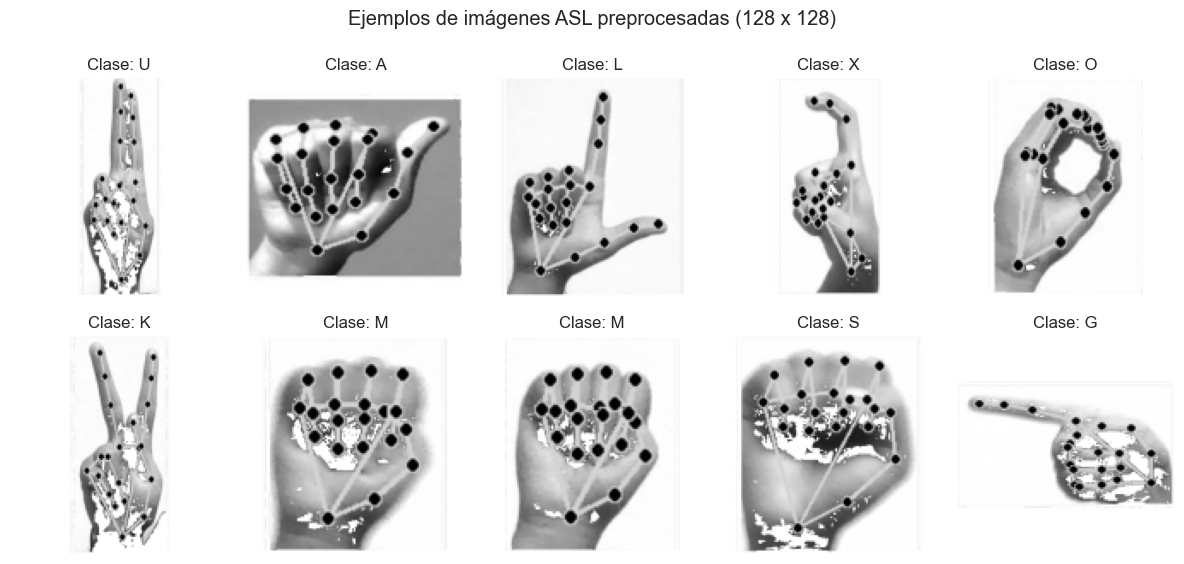

In [116]:
# Visualizar muestras aleatorias del conjunto de entrenamiento preprocesado
from IPython.display import display

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

np.random.seed(42)
random_indices = np.random.choice(len(X_train), 10, replace=False)

for ax, idx in zip(axes, random_indices):
    ax.imshow(X_train[idx], cmap="gray")
    ax.set_title(f"Clase: {y_train[idx]}")
    ax.axis("off")

fig.suptitle("Ejemplos de imágenes ASL preprocesadas (128 x 128)")
fig.tight_layout()
display(fig)
plt.close(fig)


*Muestra 10 imagenes aleatorias del conjunto de entrenamiento preprocesado para verificar visualmente que el formato (escala de grises, tamano uniforme) es correcto.*

Las muestras permiten observar que las imágenes tienen un formato homogéneo después del preprocesamiento. Todas conservan la forma general de la mano, se encuentran en escala de grises y tienen el mismo tamaño, lo cual es necesario para que los algoritmos clásicos reciban vectores de entrada comparables.


![Muestras del dataset ASL preprocesadas](reports/muestras_asl.png)

### Diagramas de barras de distribución de clases

En lugar de un *wordcloud*, que es más apropiado para datos textuales, se usan diagramas de barras, muestras de imágenes, histogramas y matriz de correlación. Para este problema de clasificación de imágenes, estas visualizaciones describen mejor la estructura del dataset.


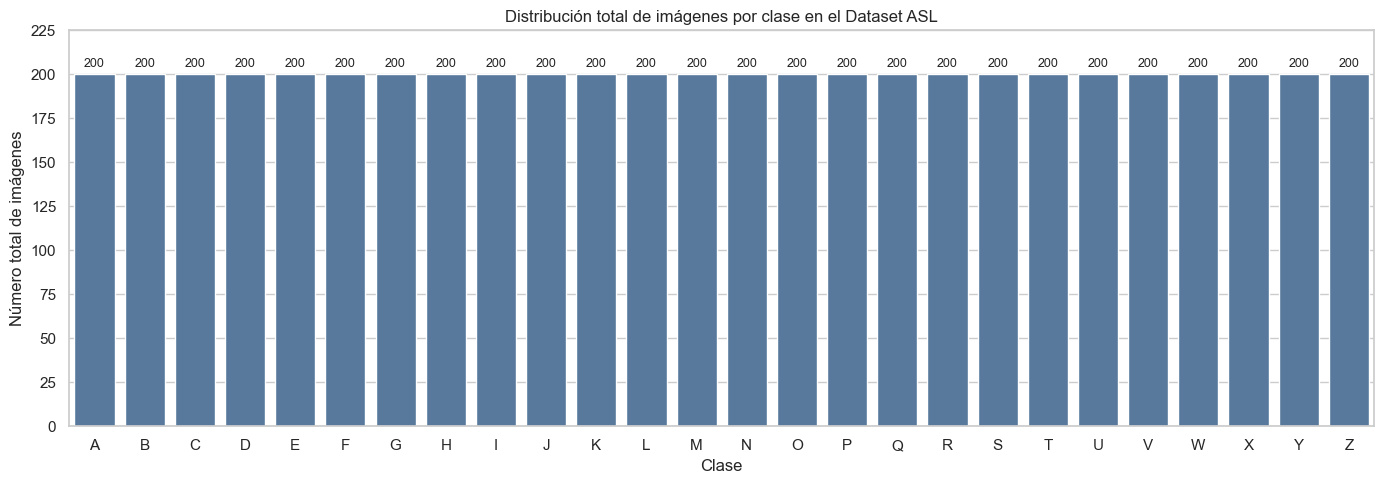

In [117]:
# Distribucion total de clases: entrenamiento + prueba
plt.figure(figsize=(14, 5))
ax = sns.barplot(
    data=class_distribution,
    x="Clase",
    y="Total",
    color="#4C78A8",
)

ax.set_title("Distribución total de imágenes por clase en el Dataset ASL")
ax.set_xlabel("Clase")
ax.set_ylabel("Número total de imágenes")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

ax.set_ylim(0, class_distribution["Total"].max() + 25)
plt.tight_layout()
plt.show()


*Genera un diagrama de barras con el total de imagenes por clase (entrenamiento + prueba), confirmando el balance del dataset ASL entre las 26 letras.*

La distribución total se obtiene sumando las imágenes de `data/train` y `data/test`. En este proyecto cada clase tiene 180 imágenes de entrenamiento y 20 imágenes de prueba, para un total de 200 imágenes por letra.


### Aclaración sobre el conjunto de validación

El proyecto no tiene una carpeta física llamada `validation`. Esto no significa que falten datos: la validación se genera de forma programática según el tipo de experimento.

- En los **modelos clásicos**, la validación se realiza mediante `GridSearchCV`, que divide internamente la submuestra de entrenamiento en folds de validación cruzada.
- En el modelo **Deep Learning VGG16**, `image_dataset_from_directory` toma el 20% de `data/train` como validación usando `validation_split=0.2`. En la ejecución local se observaron 3.744 imágenes para entrenamiento y 936 para validación.
- El conjunto `data/test` se mantiene separado y solo se usa para la evaluación final.

Por esta razón, en la exploración inicial aparecen carpetas de entrenamiento y prueba, pero la validación sí existe durante los experimentos.


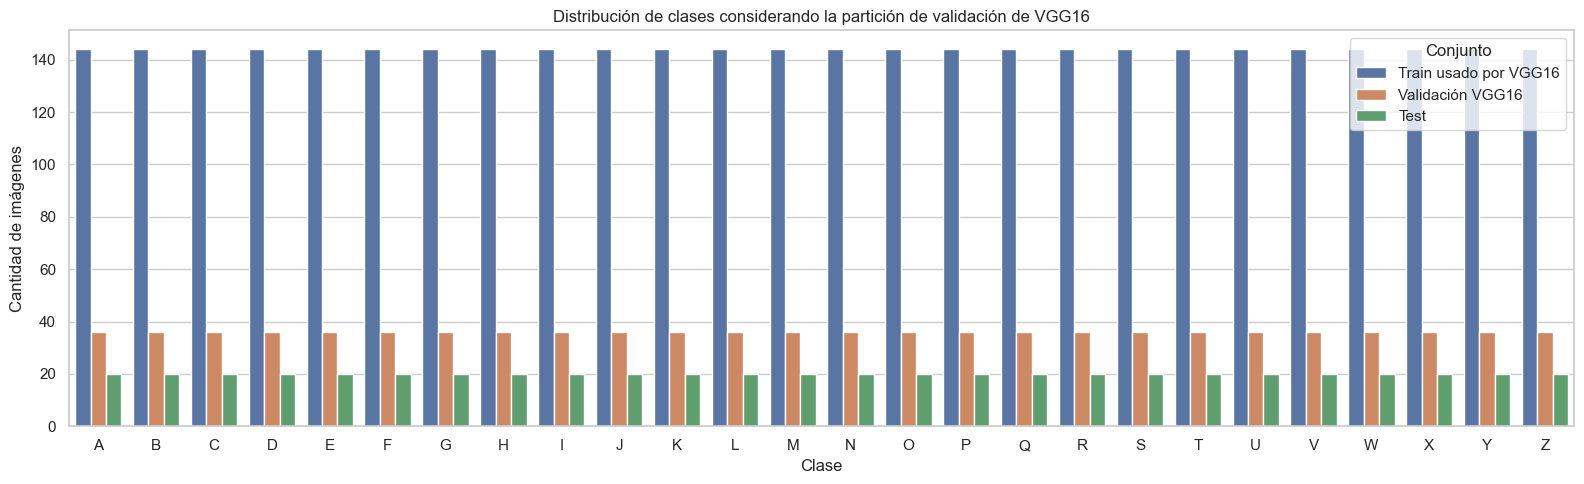

,Clase,Train usado por VGG16,Validación VGG16,Test
0,A,144,36,20
1,B,144,36,20
2,C,144,36,20
3,D,144,36,20
4,E,144,36,20
5,F,144,36,20
6,G,144,36,20
7,H,144,36,20
8,I,144,36,20
9,J,144,36,20


In [118]:
# Distribucion de referencia considerando la validacion usada por VGG16
validation_distribution = class_distribution.copy()
validation_distribution["Train usado por VGG16"] = (validation_distribution["Entrenamiento"] * 0.8).round().astype(int)
validation_distribution["Validación VGG16"] = validation_distribution["Entrenamiento"] - validation_distribution["Train usado por VGG16"]
validation_distribution["Test"] = validation_distribution["Prueba"]

validation_plot_df = validation_distribution.melt(
    id_vars="Clase",
    value_vars=["Train usado por VGG16", "Validación VGG16", "Test"],
    var_name="Conjunto",
    value_name="Cantidad de imágenes"
)

plt.figure(figsize=(16, 5))
sns.barplot(data=validation_plot_df, x="Clase", y="Cantidad de imágenes", hue="Conjunto")
plt.title("Distribución de clases considerando la partición de validación de VGG16")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.legend(title="Conjunto")
plt.tight_layout()
plt.show()

validation_distribution[["Clase", "Train usado por VGG16", "Validación VGG16", "Test"]]


![Distribución con partición train/validación](reports/distribucion_particion.png)

*Calcula y muestra la distribucion de imagenes considerando la particion 80/20 (train/validacion) que usan los modelos VGG16 y ResNet50 durante su entrenamiento.*

In [119]:
# Inspeccion de dimensiones de las imagenes originales
image_shapes = []
for label in sorted(train_counts.keys()):
    folder = os.path.join(train_dir, label)
    image_files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    for image_name in image_files[:5]:
        img = cv2.imread(os.path.join(folder, image_name))
        if img is not None:
            image_shapes.append(img.shape[:2])

shape_counts = pd.DataFrame(Counter(image_shapes).items(), columns=["Dimensión original", "Frecuencia"])
shape_counts


,Dimensión original,Frecuencia
0,"(300, 300)",130


*Lee una muestra de imagenes originales del disco y recopila sus dimensiones para mostrar la variabilidad de tamanos antes de aplicar el preprocesamiento.*

### Histograma de intensidades

El histograma permite revisar cómo se distribuyen los valores de los píxeles después del preprocesamiento. Esta visualización es pertinente porque el dataset está compuesto por imágenes y no por texto.


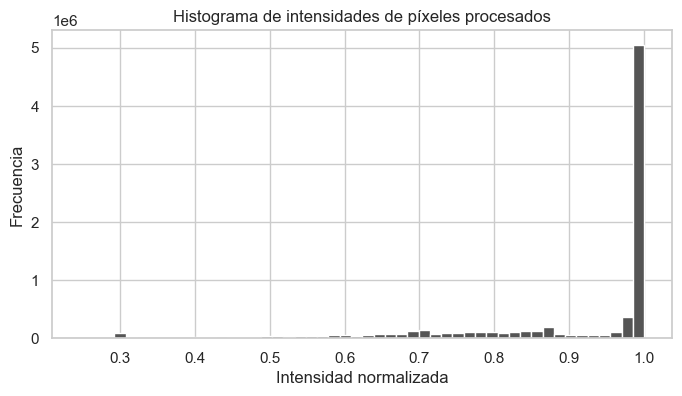

Media global de intensidad: 0.9049
Desviación estándar global: 0.1589


In [120]:
# Histograma de intensidades de pixeles despues del preprocesamiento
sample_pixels = X_train[np.random.choice(len(X_train), size=min(500, len(X_train)), replace=False)].ravel()

plt.figure(figsize=(8, 4))
plt.hist(sample_pixels, bins=50, color="#555555", edgecolor="white")
plt.title("Histograma de intensidades de píxeles procesados")
plt.xlabel("Intensidad normalizada")
plt.ylabel("Frecuencia")
plt.show()

print(f"Media global de intensidad: {sample_pixels.mean():.4f}")
print(f"Desviación estándar global: {sample_pixels.std():.4f}")


*Genera un histograma sobre una muestra aleatoria de pixeles del conjunto de entrenamiento preprocesado, mostrando la distribucion de intensidades normalizadas.*

El histograma resume la distribución de intensidades de los píxeles después de convertir las imágenes a escala de grises y normalizarlas. En este contexto, los valores cercanos a 0 representan zonas oscuras y los valores cercanos a 1 representan zonas claras. La variación en estas intensidades captura bordes, sombras y formas de la mano, que son señales útiles para diferenciar una letra de otra.


In [121]:
# Resumenes estadisticos por imagen
image_stats = pd.DataFrame({
    "clase": y_train,
    "media_intensidad": X_train.reshape(len(X_train), -1).mean(axis=1),
    "desv_intensidad": X_train.reshape(len(X_train), -1).std(axis=1),
    "min_intensidad": X_train.reshape(len(X_train), -1).min(axis=1),
    "max_intensidad": X_train.reshape(len(X_train), -1).max(axis=1)
})

image_stats.describe()


,media_intensidad,desv_intensidad,min_intensidad,max_intensidad
count,4680.000000,4680.000000,4680.000000,4680.000000
mean,0.906312,0.147898,0.294629,0.999999
std,0.048743,0.024697,0.006279,0.000057
min,0.688418,0.087491,0.168627,0.996078
25%,0.880445,0.125184,0.294118,1.000000
50%,0.919118,0.148400,0.294118,1.000000
75%,0.941635,0.167889,0.298039,1.000000
max,0.963299,0.213669,0.298039,1.000000


*Calcula estadisticas descriptivas de intensidad (media, desviacion estandar, minimo y maximo) por imagen y las resume en un DataFrame con describe().*

### Matriz de correlación

Para complementar los resúmenes estadísticos, se calcula una matriz de correlación sobre variables resumen de cada imagen: media, desviación estándar, mínimo y máximo de intensidad. No se calcula una matriz de correlación con los 16.384 píxeles originales porque sería demasiado grande y poco interpretable para el informe.


![Correlación entre características de las imágenes](reports/correlacion_caracteristicas_imagenes.png)

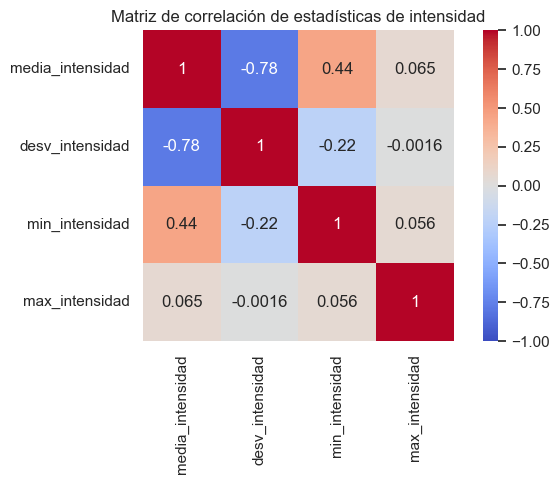

In [122]:
# Matriz de correlacion de variables resumen de las imagenes
corr = image_stats.drop(columns="clase").corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación de estadísticas de intensidad")
plt.tight_layout()
plt.show()


*Calcula y visualiza como heatmap la matriz de correlacion entre las estadisticas de intensidad, mostrando que variables resumen se mueven juntas.*

La matriz de correlación se calcula sobre variables resumen extraídas de cada imagen, no sobre todos los píxeles individuales, porque una imagen de 128 x 128 tendría 16.384 variables y una matriz completa sería poco interpretable. Esta matriz permite observar la relación entre medidas globales como media, desviación estándar, mínimo y máximo de intensidad. Estas variables no sustituyen a la imagen completa, pero ayudan a inspeccionar si existen patrones generales de iluminación o contraste que puedan influir en el aprendizaje.

Con esta inspección se concluye que el dataset está bien estructurado para un problema de clasificación multiclase: las clases están balanceadas, las imágenes fueron llevadas a un formato común y existe variabilidad visual suficiente para entrenar modelos supervisados.


---

## II. Diseño de experimentos y recolección de resultados

### 3. Estrategias de preparación de datos y reducción de dimensionalidad

A partir de la inspección realizada en la sección anterior se definieron las siguientes estrategias de preparación:

1. **Tratamiento de valores faltantes:** no se identificaron valores faltantes en las etiquetas ni imágenes inválidas dentro de los arreglos procesados. Las imágenes que no se pudieran leer se descartan durante el preprocesamiento.
2. **Uniformidad de tamaño:** las imágenes originales tienen tamaño común de 300 x 300 píxeles. Para los modelos clásicos se redimensionan a **128 x 128 píxeles** para reducir el costo computacional.
3. **Eliminación del borde magenta:** durante el preprocesamiento se recorta el marco magenta detectado en las imágenes originales, de modo que el modelo aprenda principalmente la forma de la mano y no un elemento artificial del fondo.
4. **Conversión de variables:** las imágenes se convierten a escala de grises para los modelos clásicos. Así, cada observación queda representada por una matriz de intensidades normalizadas en el rango `[0, 1]`.
5. **Balanceo del conjunto:** la exploración mostró que las clases están balanceadas: 180 imágenes por clase en entrenamiento y 20 por clase en prueba. Por esta razón no fue necesario aplicar técnicas de sobremuestreo o submuestreo para corregir desbalance.
6. **Vectorización:** cada imagen de 128 x 128 se transforma en un vector de 16.384 características, una por píxel.
7. **Selección de características:** se aplica `VarianceThreshold` para eliminar píxeles casi constantes que aportan poca información discriminativa. Este filtro elimina **columnas completas** de la matriz de datos, no píxeles aislados de una imagen particular. Es decir, si una característica se descarta, se descarta para todos los registros, manteniendo la correspondencia entre columnas e imágenes. Además, el filtro se ajusta con el conjunto de entrenamiento y luego se aplica al conjunto de prueba con `transform`, evitando usar información del test durante el ajuste.
8. **Reducción de dimensionalidad:** después del filtro cuasi-constante se aplica PCA para reducir el espacio de características a 950 componentes principales, conservando una parte importante de la variabilidad y haciendo viable el ajuste de modelos clásicos con validación cruzada.

Estas decisiones están soportadas por la inspección inicial: el dataset está balanceado, las imágenes tienen estructura homogénea, existen zonas de fondo con poca variación y las intensidades de píxeles contienen la información visual necesaria para diferenciar las señas.


In [123]:
# Librerias de modelado usadas a partir de la seccion II
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)

# Las funciones de ingenieria de caracteristicas ya fueron importadas desde src/feature_engineering.py:
# vectorize_images, remove_quasi_constant_features y apply_pca
print("Librerias de modelado y funciones del proyecto cargadas correctamente.")

Librerias de modelado y funciones del proyecto cargadas correctamente.


*Importa las librerias de scikit-learn necesarias para entrenamiento, busqueda de hiperparametros, metricas de evaluacion y visualizacion de resultados.*

In [124]:
# Vectorizacion, filtro cuasi-constante y PCA usando las funciones reales de src/feature_engineering.py
unique_classes = np.array(sorted(np.unique(y_train)))

X_train_flat = vectorize_images(X_train)
X_test_flat = vectorize_images(X_test)
print(f"Vectorizado original: Entrenamiento = {X_train_flat.shape}, Prueba = {X_test_flat.shape}")

X_train_filtered, X_test_filtered, selector = remove_quasi_constant_features(
    X_train_flat,
    X_test_flat,
    threshold=0.01
)
print(f"Filtrado (Quasi-Constant): Entrenamiento = {X_train_filtered.shape}, Prueba = {X_test_filtered.shape}")

# Mismo valor usado en src/main.py
n_components = 950
X_train_pca, X_test_pca, pca = apply_pca(
    X_train_filtered,
    X_test_filtered,
    n_components=n_components
)

print(f"Reducido con PCA: Entrenamiento = {X_train_pca.shape}, Prueba = {X_test_pca.shape}")


Vectorizado original: Entrenamiento = (4680, 16384), Prueba = (520, 16384)
Aplicando filtro VarianceThreshold (umbral de varianza = 0.01)...
Características antes: 16384 | Características después: 10930
Filtrado (Quasi-Constant): Entrenamiento = (4680, 10930), Prueba = (520, 10930)
Entrenando PCA con 950 componentes...
Varianza explicada acumulada: 0.9513
Reducido con PCA: Entrenamiento = (4680, 950), Prueba = (520, 950)


*Aplica el flujo completo de ingenieria de caracteristicas con las funciones reales del proyecto e imprime las dimensiones en cada etapa de transformacion.*

### Tabla de imagenes vectorizadas (`p0`, `p1`, `p2`, ... )

Despues de aplanar cada imagen, cada fila representa una imagen y cada columna `p0`, `p1`, `p2`, etc. representa un pixel de la imagen. Como las imagenes preprocesadas tienen tamano `128 x 128`, cada imagen queda representada por `16.384` valores de pixel.

Para evitar crear una tabla demasiado pesada, se muestra una muestra de las primeras 5 imagenes vectorizadas.


In [125]:
# Tabla tipo etiqueta, p0, p1, p2, ... para visualizar la vectorizacion
# Esta celda puede ejecutarse sola: si X_train_flat no existe, carga los datos procesados y usa vectorize_images().
if "X_train_flat" not in globals() or "y_train" not in globals():
    processed_dir = Path("data/processed")
    X_train = np.load(processed_dir / "X_train.npy")
    y_train = np.load(processed_dir / "y_train.npy")
    X_train_flat = vectorize_images(X_train)

n_muestras_tabla = 5
pixel_columns = [f"p{i}" for i in range(X_train_flat.shape[1])]

df_vectorized_sample = pd.DataFrame(
    X_train_flat[:n_muestras_tabla],
    columns=pixel_columns
)
df_vectorized_sample.insert(0, "etiqueta", y_train[:n_muestras_tabla])

print(f"Shape de la tabla vectorizada completa: ({X_train_flat.shape[0]}, {X_train_flat.shape[1] + 1})")
display(df_vectorized_sample)


Shape de la tabla vectorizada completa: (4680, 16385)


,etiqueta,p0,p1,p2,p3,p4,p5,p6,p7,p8,...,p16374,p16375,p16376,p16377,p16378,p16379,p16380,p16381,p16382,p16383
0,A,0.745098,0.686275,0.682353,0.686275,0.686275,0.686275,0.686275,0.690196,0.686275,...,0.694118,0.694118,0.694118,0.694118,0.694118,0.694118,0.694118,0.694118,0.694118,0.694118
1,A,0.741176,0.678431,0.678431,0.678431,0.682353,0.682353,0.686275,0.686275,0.686275,...,0.694118,0.694118,0.690196,0.690196,0.694118,0.694118,0.698039,0.698039,0.698039,0.698039
2,A,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,A,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,A,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


![Varianza explicada por PCA](reports/varianza_pca.png)

![Proyección 2D con PCA](reports/proyeccion_2d_pca.png)

*Genera una tabla de ejemplo donde cada fila es una imagen representada como vector (columnas p0, p1, p2...), ilustrando como queda el dato aplanado.*

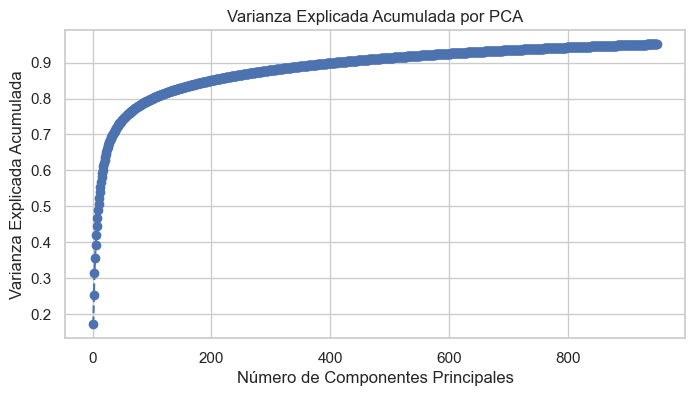

Las primeras 950 componentes explican el 95.13% de la variabilidad total de las imágenes.


In [126]:
# Graficar varianza explicada acumulada
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(range(1, n_components + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.title('Varianza Explicada Acumulada por PCA')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()

print(f"Las primeras {n_components} componentes explican el {explained_variance[-1]*100:.2f}% de la variabilidad total de las imágenes.")

*Grafica la varianza explicada acumulada en funcion del numero de componentes PCA, permitiendo evaluar cuanta informacion se retiene con la reduccion elegida.*

### 4. Ajuste de hiperparámetros usando GridSearchCV

Para los métodos clásicos vistos en clase se utiliza `GridSearchCV` con validación cruzada de 3 particiones (`cv=3`) y métrica `accuracy`. Este procedimiento automatiza la evaluación de distintas combinaciones de hiperparámetros y selecciona la configuración con mejor desempeño promedio en validación cruzada.

Los modelos ajustados son:

- Regresión logística multinomial como aproximación de regresión multivariada para clasificación.
- Árboles de decisión.
- Random Forest.
- Red neuronal clásica MLP.

La red neuronal profunda (**DNN**) se trabaja mediante transferencia de aprendizaje con VGG16 en TensorFlow/Keras. Debido al costo computacional de entrenar VGG16 múltiples veces, este experimento se ejecuta aparte en `src/main_deep.py`, usando división entrenamiento/validación y evaluación final sobre el mismo conjunto de prueba.


#### A. Regresión Lineal/Multivariada (Regresión Logística Multinomial)

In [127]:
# Busqueda de cuadricula para Regresion Logistica multinomial
param_grid_lr = {
    "C": [0.1, 1.0, 10.0],
    "solver": ["lbfgs"],
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)
grid_lr.fit(X_train_pca, y_train)

print(f"Mejores hiperparámetros LR: {grid_lr.best_params_}")
print(f"Mejor accuracy promedio en CV: {grid_lr.best_score_:.4f}")

cv_lr = pd.DataFrame(grid_lr.cv_results_)[[
    "params", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

best_lr = LogisticRegression(max_iter=1000, random_state=42, **grid_lr.best_params_)
best_lr.fit(X_train_pca, y_train)

cv_lr


Mejores hiperparámetros LR: {'C': 1.0, 'solver': 'lbfgs'}
Mejor accuracy promedio en CV: 0.9891


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
1,"{'C': 1.0, 'solver': 'lbfgs'}",1.0,0.989103,0.006036,1
2,"{'C': 10.0, 'solver': 'lbfgs'}",1.0,0.988889,0.005029,2
0,"{'C': 0.1, 'solver': 'lbfgs'}",1.0,0.987607,0.006396,3


*Ejecuta GridSearchCV con validacion cruzada de 3 pliegues para encontrar los mejores hiperparametros (C, solver) de la Regresion Logistica multinomial.*

#### Resultado: matriz de confusión de Regresión Logística

![Matriz de confusión - Regresión Logística](reports/confusion_matrix_regresion_logistica.png)


#### B. Árboles de Decisión

In [128]:
# Busqueda de cuadricula para Arboles de Decision
param_grid_dt = {
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 10],
    "criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)
grid_dt.fit(X_train_pca, y_train)

print(f"Mejores hiperparámetros DT: {grid_dt.best_params_}")
print(f"Mejor accuracy promedio en CV: {grid_dt.best_score_:.4f}")

cv_dt = pd.DataFrame(grid_dt.cv_results_)[[
    "params", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

best_dt = DecisionTreeClassifier(random_state=42, **grid_dt.best_params_)
best_dt.fit(X_train_pca, y_train)

cv_dt


Mejores hiperparámetros DT: {'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 2}
Mejor accuracy promedio en CV: 0.9485


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
2,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",1.000000,0.948504,0.032570,1
4,"{'criterion': 'gini', 'max_depth': None, 'min_...",1.000000,0.948504,0.032570,1
5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.998397,0.944444,0.027978,3
3,"{'criterion': 'gini', 'max_depth': 20, 'min_sa...",0.998397,0.944444,0.027978,3
7,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.997222,0.918162,0.014299,5
9,"{'criterion': 'entropy', 'max_depth': 20, 'min...",0.997222,0.918162,0.014299,5
11,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.997222,0.918162,0.014299,5
6,"{'criterion': 'entropy', 'max_depth': 10, 'min...",1.000000,0.917949,0.024677,8
8,"{'criterion': 'entropy', 'max_depth': 20, 'min...",1.000000,0.917949,0.024677,8
10,"{'criterion': 'entropy', 'max_depth': None, 'm...",1.000000,0.917949,0.024677,8


*Ejecuta GridSearchCV con validacion cruzada de 3 pliegues para encontrar los mejores hiperparametros (max_depth, min_samples_split, criterion) del Arbol de Decision.*

#### Resultado: matriz de confusión de Árbol de Decisión

<p align="center">
  <img src="reports/confusion_matrix_arbol_decision.png" alt="Matriz de confusión - Árbol de Decisión" width="550">
</p>


#### C. Random Forest

In [129]:
# Busqueda de cuadricula para Random Forest
param_grid_rf = {
    "n_estimators": [50, 100],
    "max_depth": [15, None],
    "min_samples_split": [2, 10],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)
grid_rf.fit(X_train_pca, y_train)

print(f"Mejores hiperparámetros RF: {grid_rf.best_params_}")
print(f"Mejor accuracy promedio en CV: {grid_rf.best_score_:.4f}")

cv_rf = pd.DataFrame(grid_rf.cv_results_)[[
    "params", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

best_rf = RandomForestClassifier(random_state=42, n_jobs=-1, **grid_rf.best_params_)
best_rf.fit(X_train_pca, y_train)

cv_rf


Mejores hiperparámetros RF: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 100}
Mejor accuracy promedio en CV: 0.9872


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
3,"{'max_depth': 15, 'min_samples_split': 10, 'n_...",1.0,0.987179,0.006432,1
1,"{'max_depth': 15, 'min_samples_split': 2, 'n_e...",1.0,0.985470,0.009101,2
7,"{'max_depth': None, 'min_samples_split': 10, '...",1.0,0.984615,0.006682,3
6,"{'max_depth': None, 'min_samples_split': 10, '...",1.0,0.983761,0.008763,4
2,"{'max_depth': 15, 'min_samples_split': 10, 'n_...",1.0,0.982479,0.009498,5
5,"{'max_depth': None, 'min_samples_split': 2, 'n...",1.0,0.981624,0.011985,6
0,"{'max_depth': 15, 'min_samples_split': 2, 'n_e...",1.0,0.981410,0.012853,7
4,"{'max_depth': None, 'min_samples_split': 2, 'n...",1.0,0.979274,0.012867,8


*Ejecuta GridSearchCV con validacion cruzada de 3 pliegues para encontrar los mejores hiperparametros (n_estimators, max_depth, min_samples_split) del Random Forest.*

## Resultado Random Forest

El modelo Random Forest fue ajustado mediante `GridSearchCV` con validación cruzada de 3 particiones. La mejor configuración encontrada fue:

| Hiperparámetro | Valor |
|---|---:|
| `n_estimators` | 100 |
| `max_depth` | 15 |
| `min_samples_split` | 10 |

Los resultados obtenidos fueron:

| Métrica | Valor |
|---|---:|
| Accuracy en validación cruzada | 98.72% |
| Accuracy en prueba | 99.81% |

#### Resultado: matriz de confusión de Random Forest

<p align="center">
  <img src="reports/confusion_matrix_random_forest.png" alt="Matriz de confusión - Random Forest" width="550">
</p>

#### D. Redes Neuronales (MLP - Multi-layer Perceptron)

In [130]:
# Busqueda de cuadricula para Red Neuronal Clasica (MLP)
param_grid_mlp = {
    "hidden_layer_sizes": [(128,), (128, 64)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
}

grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    param_grid_mlp,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)
grid_mlp.fit(X_train_pca, y_train)

print(f"Mejores hiperparámetros MLP: {grid_mlp.best_params_}")
print(f"Mejor accuracy promedio en CV: {grid_mlp.best_score_:.4f}")

cv_mlp = pd.DataFrame(grid_mlp.cv_results_)[[
    "params", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

best_mlp = MLPClassifier(max_iter=500, random_state=42, **grid_mlp.best_params_)
best_mlp.fit(X_train_pca, y_train)

cv_mlp


Mejores hiperparámetros MLP: {'alpha': 0.01, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.01}
Mejor accuracy promedio en CV: 0.9882


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
9,"{'alpha': 0.01, 'hidden_layer_sizes': (128,), ...",1.0,0.988248,0.007663,1
11,"{'alpha': 0.01, 'hidden_layer_sizes': (128, 64...",1.0,0.986538,0.006432,2
10,"{'alpha': 0.01, 'hidden_layer_sizes': (128, 64...",1.0,0.976709,0.011278,3
8,"{'alpha': 0.01, 'hidden_layer_sizes': (128,), ...",1.0,0.976282,0.014457,4
2,"{'alpha': 0.0001, 'hidden_layer_sizes': (128, ...",1.0,0.974786,0.013088,5
6,"{'alpha': 0.001, 'hidden_layer_sizes': (128, 6...",1.0,0.974786,0.012845,5
4,"{'alpha': 0.001, 'hidden_layer_sizes': (128,),...",1.0,0.973291,0.016914,7
0,"{'alpha': 0.0001, 'hidden_layer_sizes': (128,)...",1.0,0.973077,0.017113,8
1,"{'alpha': 0.0001, 'hidden_layer_sizes': (128,)...",1.0,0.968162,0.018699,9
5,"{'alpha': 0.001, 'hidden_layer_sizes': (128,),...",1.0,0.968162,0.018699,9


*Ejecuta GridSearchCV con validacion cruzada de 3 pliegues para encontrar los mejores hiperparametros (hidden_layer_sizes, alpha, learning_rate_init) del MLP.*

#### Resultado: matriz de confusión de MLP

<p align="center">
  <img src="reports/confusion_matrix_mlp.png" alt="Matriz de confusión - MLP" width="550">
</p>


### Comparación de hiperparámetros evaluados

Siguiendo la lógica del notebook de referencia, no basta con mostrar únicamente el mejor modelo. También se resume cómo se comportaron las combinaciones de hiperparámetros probadas durante `GridSearchCV`. Esto permite observar estabilidad, sobreajuste y diferencia entre entrenamiento y validación cruzada.

### Matriz de confusión - Modelos clásicos combinados

<p align="center">
  <img src="reports/confusion_matrix_classic.png" alt="Matriz de confusión - Modelos clásicos" width="550">
</p>

#### Correlación entre hiperparámetros y métricas

<p align="center">
  <img src="reports/correlacion_hiperparametros_metricas.png" alt="Correlación hiperparámetros y métricas" width="550">
</p>

In [131]:
# Resumen comparativo de las combinaciones evaluadas en GridSearchCV
def summarize_grid_results(cv_df, model_name):
    temp = cv_df.copy()
    temp["Modelo"] = model_name
    temp["Gap train-test"] = temp["mean_train_score"] - temp["mean_test_score"]
    return temp[[
        "Modelo", "params", "mean_train_score", "mean_test_score",
        "std_test_score", "Gap train-test", "rank_test_score"
    ]]

df_gridsearch_summary = pd.concat([
    summarize_grid_results(cv_lr, "Regresión Logística"),
    summarize_grid_results(cv_dt, "Árbol de Decisión"),
    summarize_grid_results(cv_rf, "Random Forest"),
    summarize_grid_results(cv_mlp, "MLP"),
], ignore_index=True)

df_gridsearch_top = df_gridsearch_summary.sort_values(["Modelo", "rank_test_score"]).groupby("Modelo").head(5)
df_gridsearch_top

,Modelo,params,mean_train_score,mean_test_score,std_test_score,Gap train-test,rank_test_score
23,MLP,"{'alpha': 0.01, 'hidden_layer_sizes': (128,), ...",1.000000,0.988248,0.007663,0.011752,1
24,MLP,"{'alpha': 0.01, 'hidden_layer_sizes': (128, 64...",1.000000,0.986538,0.006432,0.013462,2
25,MLP,"{'alpha': 0.01, 'hidden_layer_sizes': (128, 64...",1.000000,0.976709,0.011278,0.023291,3
26,MLP,"{'alpha': 0.01, 'hidden_layer_sizes': (128,), ...",1.000000,0.976282,0.014457,0.023718,4
27,MLP,"{'alpha': 0.0001, 'hidden_layer_sizes': (128, ...",1.000000,0.974786,0.013088,0.025214,5
15,Random Forest,"{'max_depth': 15, 'min_samples_split': 10, 'n_...",1.000000,0.987179,0.006432,0.012821,1
16,Random Forest,"{'max_depth': 15, 'min_samples_split': 2, 'n_e...",1.000000,0.985470,0.009101,0.014530,2
17,Random Forest,"{'max_depth': None, 'min_samples_split': 10, '...",1.000000,0.984615,0.006682,0.015385,3
18,Random Forest,"{'max_depth': None, 'min_samples_split': 10, '...",1.000000,0.983761,0.008763,0.016239,4
19,Random Forest,"{'max_depth': 15, 'min_samples_split': 10, 'n_...",1.000000,0.982479,0.009498,0.017521,5


*Define una funcion auxiliar que extrae y consolida los resultados del GridSearchCV de cada modelo en un DataFrame con el gap train-test y el ranking de configuraciones.*

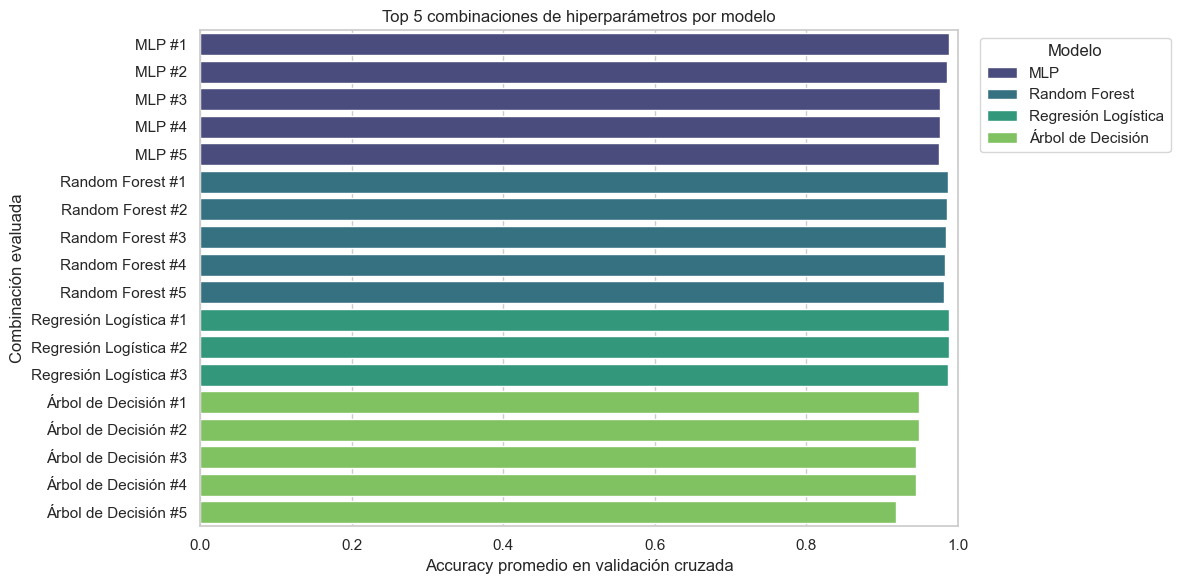

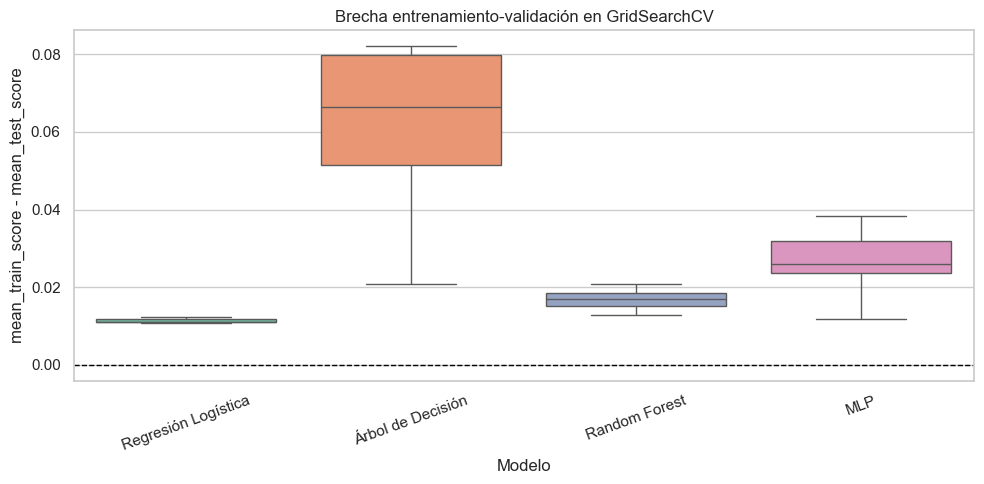

In [132]:
# Grafica de las mejores combinaciones de hiperparametros por modelo
plot_grid = df_gridsearch_top.copy()
plot_grid["Configuración"] = plot_grid.groupby("Modelo").cumcount() + 1
plot_grid["Modelo + config"] = plot_grid["Modelo"] + " #" + plot_grid["Configuración"].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_grid,
    x="mean_test_score",
    y="Modelo + config",
    hue="Modelo",
    dodge=False,
    palette="viridis"
)
plt.xlim(0, 1.0)
plt.xlabel("Accuracy promedio en validación cruzada")
plt.ylabel("Combinación evaluada")
plt.title("Top 5 combinaciones de hiperparámetros por modelo")
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_gridsearch_summary,
    x="Modelo",
    y="Gap train-test",
    hue="Modelo",
    palette="Set2",
    legend=False
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Brecha entrenamiento-validación en GridSearchCV")
plt.ylabel("mean_train_score - mean_test_score")
plt.xlabel("Modelo")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

*Grafica las mejores configuraciones de hiperparametros por modelo segun el score de validacion cruzada, facilitando la comparacion visual entre algoritmos.*

#### E. Redes Neuronales Profundas: VGG16 y ResNet50

Para comparar arquitecturas de *Deep Learning*, se evalúan los modelos guardados de VGG16 y ResNet50 entrenados mediante *transfer learning*. Ambos trabajan con imágenes RGB de `128 x 128` y se comparan con las mismas métricas usadas en los modelos clásicos.


In [133]:
# Evaluacion de modelos Deep Learning guardados: VGG16 y ResNet50
import tensorflow as tf
from models_keras import load_test_dataset_rgb

X_test_rgb, y_test_rgb = load_test_dataset_rgb(
    "data/test",
    img_size=IMG_SIZE,
    class_names=list(unique_classes)
)
y_true_deep = np.argmax(y_test_rgb, axis=1)
deep_labels = list(unique_classes)
y_true_deep_labels = np.array([deep_labels[i] for i in y_true_deep])

deep_model_paths = {
    "VGG16 (Deep Learning)": ["models/keras_vgg16_model.keras", "models/keras_vgg16_model.h5"],
    "ResNet50 (Deep Learning)": ["models/keras_resnet50_model.keras", "models/keras_resnet50_model.h5"],
}

deep_results = {}
deep_predictions = {}
deep_classification_reports = {}
deep_probs = {}

for model_name, candidate_paths in deep_model_paths.items():
    model_path = next((p for p in candidate_paths if os.path.exists(p)), None)
    if model_path is None:
        print(f"[!] No se encontró modelo guardado para {model_name}.")
        continue

    print(f"[+] Cargando {model_name} desde {model_path}...")
    model = tf.keras.models.load_model(model_path)
    y_pred_probs = model.predict(X_test_rgb)
    y_pred_idx = np.argmax(y_pred_probs, axis=1)
    y_pred_labels = np.array([deep_labels[i] for i in y_pred_idx])

    deep_predictions[model_name] = y_pred_labels
    deep_probs[model_name] = y_pred_probs
    deep_results[model_name] = {
        "Accuracy": accuracy_score(y_true_deep_labels, y_pred_labels),
        "Precision macro": precision_score(y_true_deep_labels, y_pred_labels, average="macro", zero_division=0),
        "Recall macro": recall_score(y_true_deep_labels, y_pred_labels, average="macro", zero_division=0),
        "F1 macro": f1_score(y_true_deep_labels, y_pred_labels, average="macro", zero_division=0),
    }
    deep_classification_reports[model_name] = classification_report(
        y_true_deep_labels,
        y_pred_labels,
        zero_division=0
    )
    print(f"Precisión general de {model_name}: {deep_results[model_name]['Accuracy']:.4f}")

pd.DataFrame(deep_results).T


[+] Cargando VGG16 (Deep Learning) desde models/keras_vgg16_model.keras...
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 557ms/step
Precisión general de VGG16 (Deep Learning): 0.8808
[+] Cargando ResNet50 (Deep Learning) desde models/keras_resnet50_model.keras...
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 303ms/step
Precisión general de ResNet50 (Deep Learning): 0.9673


,Accuracy,Precision macro,Recall macro,F1 macro
VGG16 (Deep Learning),0.880769,0.884969,0.880769,0.863866
ResNet50 (Deep Learning),0.967308,0.975441,0.967308,0.967697


*Carga los modelos VGG16 y ResNet50 entrenados, evalua su desempeno sobre el conjunto de prueba en formato RGB y recopila metricas y predicciones.*

### Gráficas de comparación de hiperparámetros CNN

Estas gráficas resumen los experimentos realizados con VGG16 y ResNet50 variando épocas, batch size y configuración general del entrenamiento.

#### Efecto del número de épocas

<p align="center">
  <img src="reports/efecto_epocas_accuracy.png" alt="Efecto de épocas sobre accuracy" width="550">
</p>

#### Efecto del batch size

<p align="center">
  <img src="reports/efecto_batch_size_accuracy.png" alt="Efecto del batch size sobre accuracy" width="550">
</p>

#### Heatmap de configuraciones

<p align="center">
  <img src="reports/heatmap_accuracy_configuraciones.png" alt="Heatmap de accuracy por configuración" width="550">
</p>

#### Efecto del learning rate

<p align="center">
  <img src="reports/efecto_learning_rate_accuracy.png" alt="Efecto del learning rate sobre accuracy" width="550">
</p>

#### Curvas de aprendizaje - VGG16

<p align="center">
  <img src="reports/learning_curves_vgg16.png" alt="Learning curves VGG16" width="550">
</p>

<p align="center">
  <img src="reports/learning_curves_3vgg16.png" alt="Learning curves VGG16 experimento 3" width="550">
</p>

<p align="center">
  <img src="reports/learning_curves_4vgg16.png" alt="Learning curves VGG16 experimento 4" width="550">
</p>

#### Curvas de aprendizaje - ResNet50

<p align="center">
  <img src="reports/learning_curves_5resnet50.png" alt="Learning curves ResNet50 experimento 5" width="550">
</p>

<p align="center">
  <img src="reports/learning_curves_6resnet50.png" alt="Learning curves ResNet50 experimento 6" width="550">
</p>

<p align="center">
  <img src="reports/learning_curves_7resnet50.png" alt="Learning curves ResNet50 experimento 7" width="550">
</p>

<p align="center">
  <img src="reports/learning_curves_8resnet50.png" alt="Learning curves ResNet50 experimento 8" width="550">
</p>

### Matrices de confusión de los mejores modelos CNN

Las siguientes matrices corresponden a los mejores experimentos de cada arquitectura profunda: VGG16 en el experimento 2 y ResNet50 en el experimento 6.

#### VGG16 - Experimento 2

<p align="center">
  <img src="reports/confusion_matrix_best_vgg16.png" alt="Matriz de confusión - Mejor VGG16" width="550">
</p>

#### ResNet50 - Experimento 6

<p align="center">
  <img src="reports/confusion_matrix_best_resnet50.png" alt="Matriz de confusión - Mejor ResNet50" width="550">
</p>

---

## III. Comparación entre los modelos

### 5. Explicación y análisis de resultados obtenidos

En esta sección se evalúa cada modelo sobre el conjunto de prueba independiente. Para comparar los experimentos se calculan las siguientes métricas:

- **Accuracy:** proporción total de imágenes clasificadas correctamente.
- **Precision macro:** promedio de la precisión por clase; indica qué tan confiables son las predicciones positivas de cada letra.
- **Recall macro:** promedio del recall por clase; indica qué proporción de imágenes reales de cada letra fueron recuperadas correctamente.
- **F1 macro:** promedio armónico entre precision y recall; resume el equilibrio entre ambas.
- **Matriz de confusión:** permite identificar qué letras se confunden entre sí.

Como el conjunto de prueba está balanceado, el accuracy es una métrica útil. Aun así, se incluyen precision, recall y F1 macro para verificar que el desempeño sea uniforme entre clases.


In [134]:
# Evaluar los mejores estimadores clasicos y unirlos con los modelos deep learning
models = {
    "Regresión Logística": best_lr,
    "Árbol de Decisión": best_dt,
    "Random Forest": best_rf,
    "Red Neuronal MLP": best_mlp,
}

results = {}
y_pred_by_model = {}
y_true_by_model = {}
classification_reports = {}

for name, clf in models.items():
    y_pred = clf.predict(X_test_pca)
    y_pred_by_model[name] = y_pred
    y_true_by_model[name] = y_test
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    }
    classification_reports[name] = classification_report(y_test, y_pred, zero_division=0)

# Agregar VGG16 y ResNet50 si fueron cargados en la sección anterior
if "deep_results" in globals():
    for name, metrics in deep_results.items():
        results[name] = metrics
        y_pred_by_model[name] = deep_predictions[name]
        y_true_by_model[name] = y_true_deep_labels
        classification_reports[name] = deep_classification_reports[name]

df_metrics = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
df_metrics

,Accuracy,Precision macro,Recall macro,F1 macro
Regresión Logística,1.000000,1.000000,1.000000,1.000000
Red Neuronal MLP,1.000000,1.000000,1.000000,1.000000
Random Forest,0.998077,0.998168,0.998077,0.998076
Árbol de Decisión,0.994231,0.994672,0.994231,0.994220
ResNet50 (Deep Learning),0.967308,0.975441,0.967308,0.967697
VGG16 (Deep Learning),0.880769,0.884969,0.880769,0.863866


*Evalua los cuatro clasificadores clasicos (LR, DT, RF, MLP) sobre el conjunto de prueba, calcula accuracy, precision, recall y F1, y los une con los resultados de DL.*

La tabla anterior resume el desempeño general de cada experimento. Si un modelo presenta valores altos y similares en accuracy, precision macro, recall macro y F1 macro, significa que no solo acierta muchas imágenes en total, sino que además mantiene un comportamiento equilibrado entre las diferentes letras.

En este problema, las diferencias entre precision y recall son importantes: una precision baja en una clase indicaría que el modelo predice esa letra cuando no corresponde, mientras que un recall bajo indicaría que el modelo deja de reconocer imágenes que realmente pertenecen a esa letra.


In [135]:
# Reporte detallado de precision, recall y F1-score por clase
for name, report in classification_reports.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    print(report)


Regresión Logística
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        20
           B       1.00      1.00      1.00        20
           C       1.00      1.00      1.00        20
           D       1.00      1.00      1.00        20
           E       1.00      1.00      1.00        20
           F       1.00      1.00      1.00        20
           G       1.00      1.00      1.00        20
           H       1.00      1.00      1.00        20
           I       1.00      1.00      1.00        20
           J       1.00      1.00      1.00        20
           K       1.00      1.00      1.00        20
           L       1.00      1.00      1.00        20
           M       1.00      1.00      1.00        20
           N       1.00      1.00      1.00        20
           O       1.00      1.00      1.00        20
           P       1.00      1.00      1.00        20
           Q       1.00      1.00      1.00        20
       

*Imprime el reporte completo de clasificacion (precision, recall, F1-score por clase y promedios macro/weighted) para cada modelo evaluado.*

### Análisis por experimento

**Regresión Logística:** este modelo funciona como una base lineal fuerte después de aplicar PCA. Si obtiene buen accuracy, significa que las componentes principales separan adecuadamente las clases. Su ventaja es la simplicidad e interpretabilidad; su limitación es que solo modela fronteras lineales en el espacio reducido.

**Árbol de Decisión:** este modelo divide el espacio mediante reglas jerárquicas. Suele ser más sensible al sobreajuste, especialmente si se permite mucha profundidad. Por eso se ajustan hiperparámetros como `max_depth` y `min_samples_split`. Si su matriz de confusión muestra más errores, esto indica que las reglas aprendidas no generalizan tan bien a imágenes nuevas.

**Random Forest:** combina varios árboles y reduce la varianza del árbol individual. Normalmente debería ser más estable que un árbol de decisión simple. Si mejora precision y recall frente al árbol, significa que el ensamble está reduciendo errores causados por decisiones demasiado específicas.

**Red Neuronal MLP:** aprende relaciones no lineales entre las componentes PCA. Su rendimiento depende de la arquitectura, la regularización `alpha` y la tasa de aprendizaje. Un buen resultado indica que las características reducidas siguen conservando patrones suficientes para distinguir las letras.

**DNN / VGG16:** este modelo trabaja directamente con estructura espacial RGB y aprovecha filtros visuales preentrenados. Si supera a los modelos clásicos, indica que las características convolucionales capturan mejor bordes, texturas y formas. Si queda por debajo, puede deberse al bajo número de épocas, al tamaño limitado del dataset local o a que los modelos clásicos con PCA ya separan muy bien estas imágenes controladas.


![Comparación accuracy - todos los experimentos](reports/comparacion_accuracy_experimentos.png)

![Ranking de experimentos por accuracy](reports/ranking_experimentos_accuracy.png)

### 6. Tabla y gráficos de comparación de modelos

In [136]:
# Crear tabla comparativa ordenada por accuracy
df_comparison = df_metrics.reset_index().rename(columns={"index": "Modelo/Algoritmo"})
df_comparison


,Modelo/Algoritmo,Accuracy,Precision macro,Recall macro,F1 macro
0,Regresión Logística,1.000000,1.000000,1.000000,1.000000
1,Red Neuronal MLP,1.000000,1.000000,1.000000,1.000000
2,Random Forest,0.998077,0.998168,0.998077,0.998076
3,Árbol de Decisión,0.994231,0.994672,0.994231,0.994220
4,ResNet50 (Deep Learning),0.967308,0.975441,0.967308,0.967697
5,VGG16 (Deep Learning),0.880769,0.884969,0.880769,0.863866


![Comparación de métricas macro - todos los experimentos](reports/comparacion_metricas_macro_experimentos.png)

*Construye y muestra una tabla comparativa con las metricas de todos los modelos, ordenada de mayor a menor exactitud en el conjunto de prueba.*

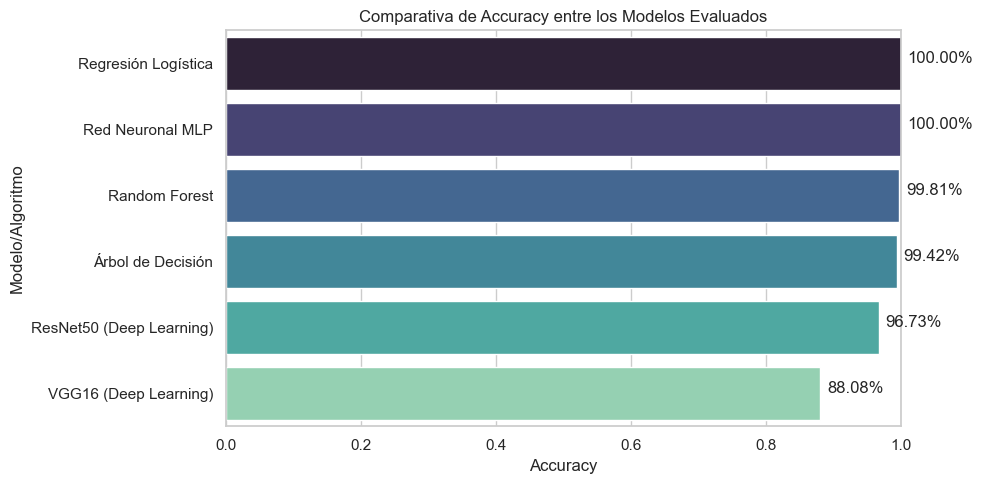

In [137]:
# Graficar comparacion de desempeno
plt.figure(figsize=(10, 5))
sns.barplot(
    x="Accuracy",
    y="Modelo/Algoritmo",
    hue="Modelo/Algoritmo",
    data=df_comparison,
    palette="mako",
    legend=False
)
plt.xlim(0.0, 1.0)
plt.title("Comparativa de Accuracy entre los Modelos Evaluados")
for index, row in df_comparison.iterrows():
    plt.text(row["Accuracy"] + 0.01, index, f"{row['Accuracy']*100:.2f}%")
plt.tight_layout()
plt.show()


*Genera un grafico de barras horizontales comparando la exactitud (accuracy) de todos los modelos evaluados, con etiquetas de porcentaje en cada barra.*

### Gráficos adicionales de comparación

Tomando como guía el notebook de referencia, se agregan gráficos que comparan más que el accuracy: ranking por F1 macro, comparación de todas las métricas principales, desempeño por clase y un diagrama radar entre los dos mejores modelos.

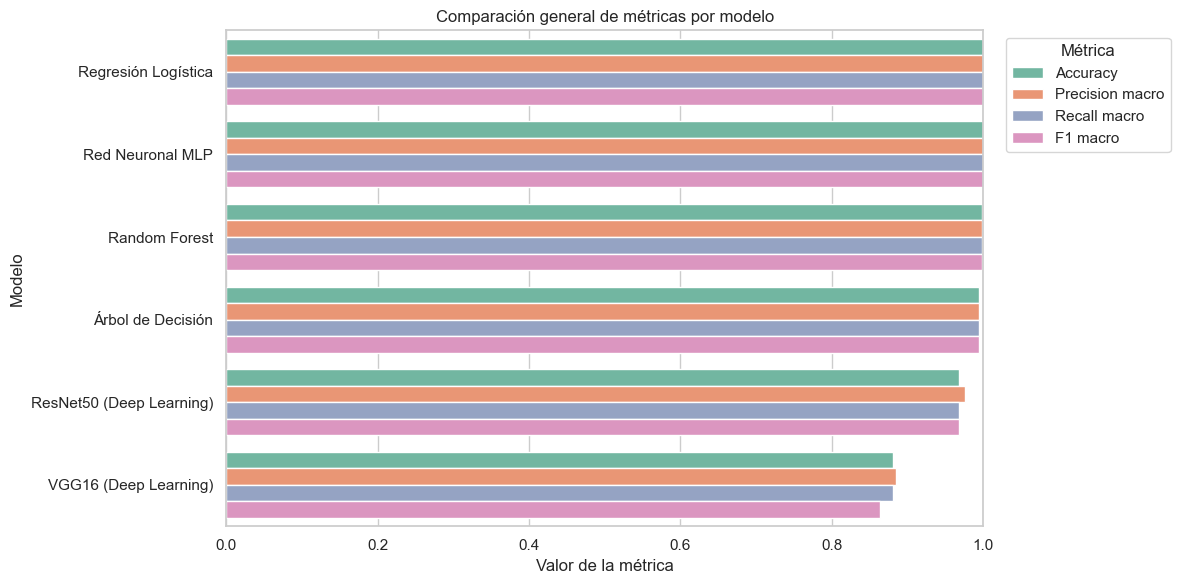

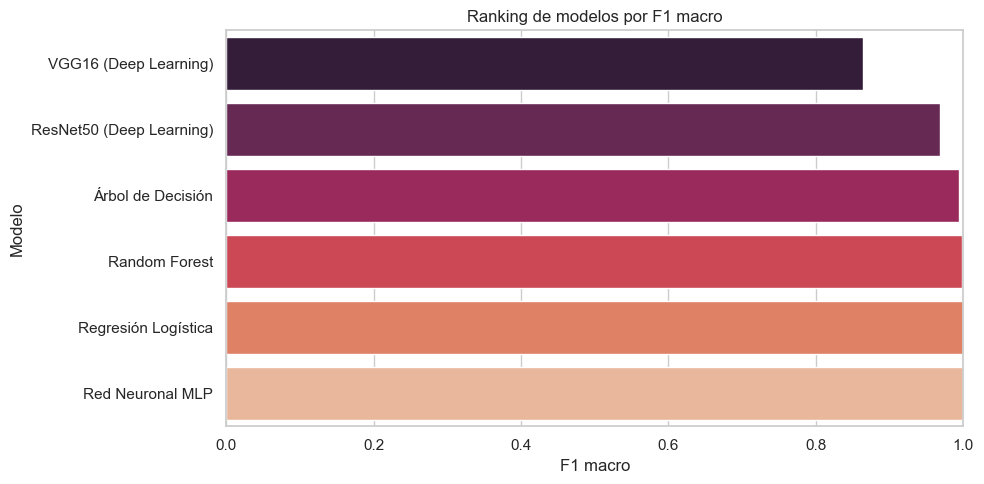

In [138]:
# Comparacion agrupada de Accuracy, Precision, Recall y F1 macro
df_metric_long = (
    df_metrics.reset_index()
    .rename(columns={"index": "Modelo"})
    .melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")
)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_metric_long, x="Valor", y="Modelo", hue="Métrica", palette="Set2")
plt.xlim(0, 1.0)
plt.title("Comparación general de métricas por modelo")
plt.xlabel("Valor de la métrica")
plt.ylabel("Modelo")
plt.legend(title="Métrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
df_f1_rank = df_metrics.sort_values("F1 macro", ascending=True).reset_index().rename(columns={"index": "Modelo"})
sns.barplot(
    data=df_f1_rank,
    x="F1 macro",
    y="Modelo",
    hue="Modelo",
    palette="rocket",
    legend=False
)
plt.xlim(0, 1.0)
plt.title("Ranking de modelos por F1 macro")
plt.xlabel("F1 macro")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

*Genera un grafico de barras agrupadas que compara Accuracy, Precision, Recall y F1-macro para todos los modelos, ofreciendo una vision integral del desempeno.*

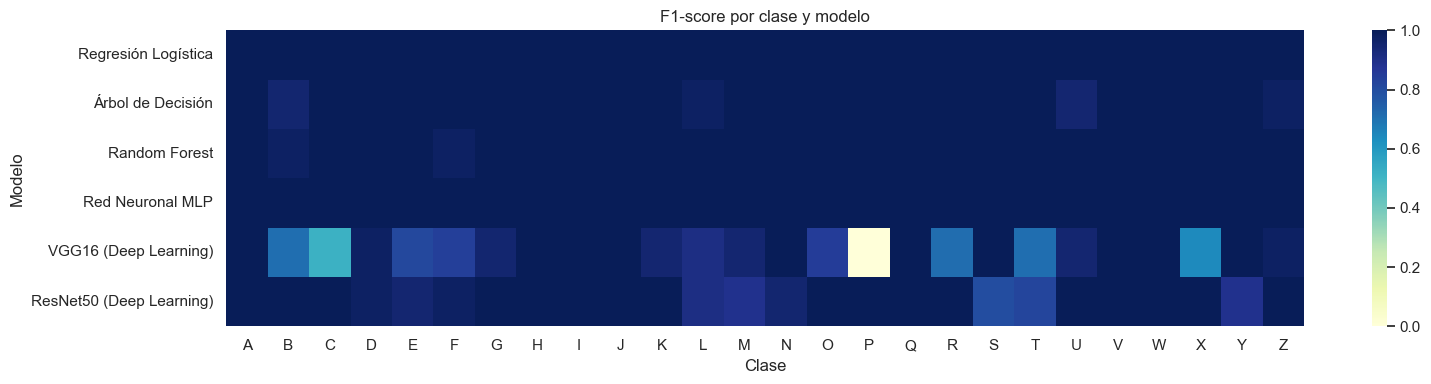

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
Regresión Logística,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.0,1.0,1.0,...,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.00000
Árbol de Decisión,1.0,0.952381,1.000000,1.00000,1.000000,1.000000,1.000000,1.0,1.0,1.0,...,1.0,1.000000,1.0,1.000000,0.947368,1.0,1.0,1.000000,1.000000,0.97561
Random Forest,1.0,0.975610,1.000000,1.00000,1.000000,0.974359,1.000000,1.0,1.0,1.0,...,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.00000
Red Neuronal MLP,1.0,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.0,1.0,1.0,...,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.00000
VGG16 (Deep Learning),1.0,0.709677,0.518519,0.97561,0.816327,0.842105,0.952381,1.0,1.0,1.0,...,1.0,0.714286,1.0,0.709677,0.947368,1.0,1.0,0.644068,1.000000,0.97561
ResNet50 (Deep Learning),1.0,1.000000,1.000000,0.97561,0.947368,0.974359,1.000000,1.0,1.0,1.0,...,1.0,1.000000,0.8,0.823529,1.000000,1.0,1.0,1.000000,0.888889,1.00000


In [139]:
# Heatmap de F1-score por clase para comparar errores especificos
per_class_f1 = {}
for name, y_pred_model in y_pred_by_model.items():
    y_true_model = y_true_by_model[name]
    report_dict = classification_report(
        y_true_model,
        y_pred_model,
        labels=list(unique_classes),
        output_dict=True,
        zero_division=0
    )
    per_class_f1[name] = {cls: report_dict[cls]["f1-score"] for cls in unique_classes}

df_per_class_f1 = pd.DataFrame(per_class_f1).T

plt.figure(figsize=(16, max(4, 0.55 * len(df_per_class_f1))))
sns.heatmap(df_per_class_f1, annot=False, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("F1-score por clase y modelo")
plt.xlabel("Clase")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

df_per_class_f1

*Genera un heatmap donde cada fila es un modelo y cada columna es una clase (letra), mostrando el F1-score para identificar las clases con mayor tasa de error.*

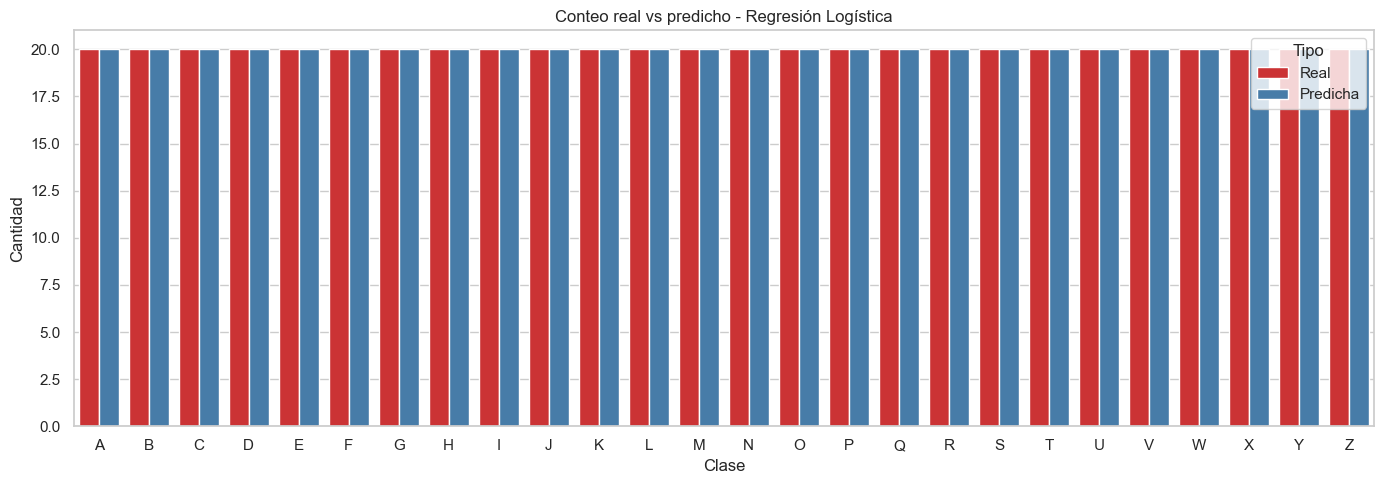

,Clase,Real,Predicha
0,A,20,20
1,B,20,20
2,C,20,20
3,D,20,20
4,E,20,20
5,F,20,20
6,G,20,20
7,H,20,20
8,I,20,20
9,J,20,20


In [140]:
# Conteo de clases reales vs predichas para el mejor modelo
best_model_name = df_metrics.index[0]
best_true = pd.Series(y_true_by_model[best_model_name], name="Real")
best_pred = pd.Series(y_pred_by_model[best_model_name], name="Predicha")

count_compare = pd.DataFrame({
    "Real": best_true.value_counts().reindex(unique_classes, fill_value=0),
    "Predicha": best_pred.value_counts().reindex(unique_classes, fill_value=0),
}).reset_index().rename(columns={"index": "Clase"})

count_compare_long = count_compare.melt(id_vars="Clase", var_name="Tipo", value_name="Cantidad")

plt.figure(figsize=(14, 5))
sns.barplot(data=count_compare_long, x="Clase", y="Cantidad", hue="Tipo", palette="Set1")
plt.title(f"Conteo real vs predicho - {best_model_name}")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

count_compare

*Compara el numero de imagenes reales versus predichas por clase del mejor modelo, mostrando si el clasificador tiende a sobre o sub-predecir alguna letra.*

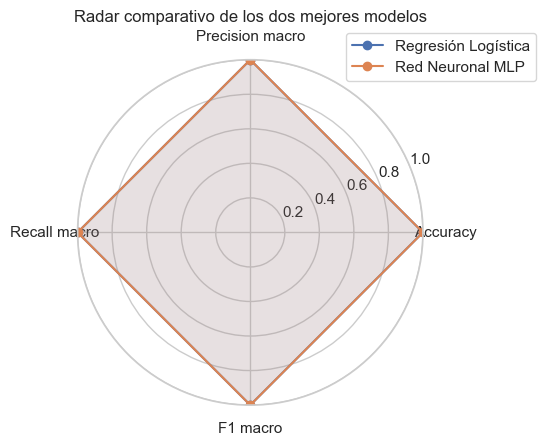

In [141]:
# Diagrama radar entre los dos mejores modelos por Accuracy
radar_metrics = ["Accuracy", "Precision macro", "Recall macro", "F1 macro"]
top2 = df_metrics.head(2)
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
for model_name, row in top2.iterrows():
    values = [row[m] for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, marker="o", label=model_name)
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics)
ax.set_ylim(0, 1)
ax.set_title("Radar comparativo de los dos mejores modelos")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

*Genera un diagrama de radar (spider chart) que compara Accuracy, Precision, Recall y F1-macro entre los dos mejores modelos, destacando sus fortalezas y debilidades.*

### 6b. Matrices de confusión

Las matrices de confusión permiten observar los errores específicos de clasificación. La diagonal principal representa aciertos; los valores fuera de la diagonal indican confusiones entre letras. En un buen clasificador se espera una diagonal dominante y pocos valores fuera de ella.


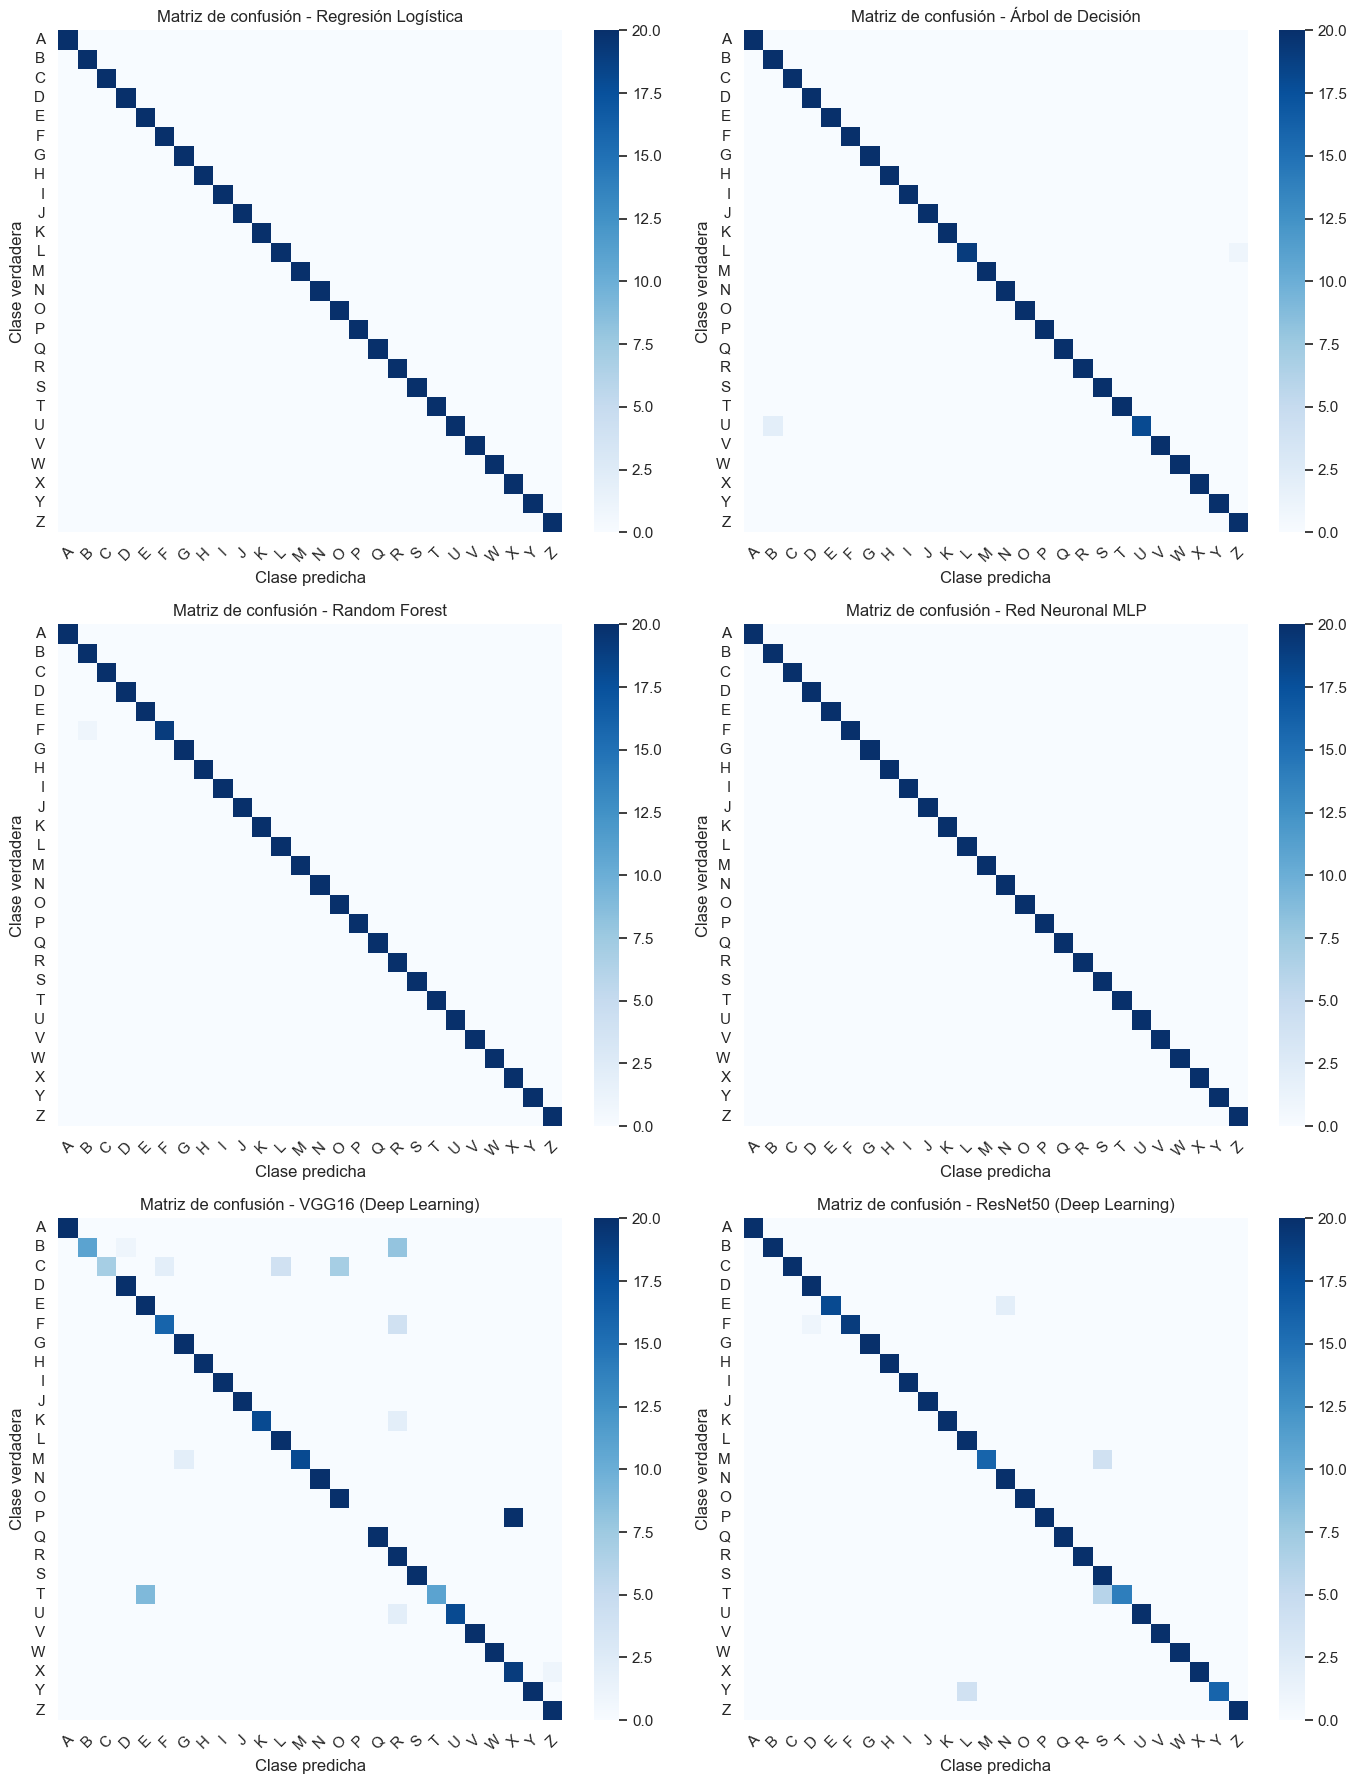

In [142]:
# Matrices de confusion para todos los modelos evaluados
n_models = len(y_pred_by_model)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (name, y_pred_model) in zip(axes, y_pred_by_model.items()):
    y_true_model = y_true_by_model[name]
    cm = confusion_matrix(y_true_model, y_pred_model, labels=list(unique_classes))
    sns.heatmap(
        cm,
        annot=False,
        fmt="d",
        cmap="Blues",
        xticklabels=list(unique_classes),
        yticklabels=list(unique_classes),
        cbar=True,
        ax=ax,
    )
    ax.set_title(f"Matriz de confusión - {name}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase verdadera")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("reports/confusion_matrices_all_models.png", dpi=300)
plt.show()

*Genera una matriz de confusion para cada modelo evaluado, permitiendo visualizar en detalle que clases (letras) se confunden entre si con mayor frecuencia.*

En el análisis de las matrices de confusión se debe revisar especialmente qué letras presentan errores fuera de la diagonal. En lenguaje de señas, algunas letras pueden tener posturas visualmente parecidas, por lo que las confusiones no solo indican fallas del algoritmo, sino también similitud visual entre clases. Si los errores se concentran en pocas letras, el modelo podría mejorar con más ejemplos de esas clases, aumento de datos o un preprocesamiento más centrado en la mano.


## IV. Conclusiones

El presente trabajo tuvo como propósito analizar, entrenar y evaluar diferentes modelos de aprendizaje supervisado para el reconocimiento de letras del Lenguaje de Señas Americano (ASL), utilizando un conjunto de datos compuesto por imágenes de manos que representan las letras del alfabeto de la `A` a la `Z`.

A lo largo del proyecto se realizó la inspección del conjunto de datos, el preprocesamiento de las imágenes y el entrenamiento de diferentes modelos de clasificación. Para los modelos clásicos se aplicaron transformaciones como eliminación del borde magenta, redimensionamiento, conversión a escala de grises, normalización, vectorización, eliminación de características cuasi-constantes y reducción de dimensionalidad mediante PCA. Estas etapas permitieron transformar las imágenes en datos numéricos adecuados para el entrenamiento de los modelos.

Durante el desarrollo se entrenaron y compararon modelos como Regresión Logística Multinomial, Árbol de Decisión, Random Forest y Red Neuronal MLP, utilizando `GridSearchCV` para ajustar los hiperparámetros y seleccionar las mejores configuraciones. Además, se realizaron experimentos con modelos profundos basados en redes convolucionales, específicamente VGG16 y ResNet50, con el fin de comparar el desempeño de enfoques clásicos y profundos en el problema de clasificación de imágenes.

Los resultados obtenidos muestran que los modelos clásicos presentaron un desempeño muy alto sobre el conjunto de prueba. En particular, Regresión Logística y MLP alcanzaron una exactitud del 100%, mientras que Random Forest obtuvo aproximadamente 99.81% y Árbol de Decisión cerca de 99.42%. Estos resultados indican que, para este conjunto de datos balanceado y en condiciones controladas, las características obtenidas mediante el preprocesamiento y PCA fueron suficientes para diferenciar adecuadamente las clases del alfabeto ASL.

En general, los modelos clásicos lograron mejores resultados que los modelos profundos evaluados. Esto puede explicarse por la naturaleza del dataset, ya que las imágenes presentan cierta uniformidad, las clases están balanceadas y el preprocesamiento aplicado permitió reducir el ruido y conservar información relevante. En este contexto, modelos como Regresión Logística y MLP fueron capaces de encontrar patrones suficientemente claros para separar las letras.

Por otro lado, los modelos profundos también obtuvieron resultados importantes, aunque inferiores a los mejores modelos clásicos. ResNet50 presentó un mejor desempeño que VGG16, alcanzando aproximadamente 96.73% de exactitud, mientras que VGG16 obtuvo cerca de 88.08%. Esto muestra que ResNet50 tuvo mayor capacidad de generalización dentro de los experimentos realizados, posiblemente debido a su arquitectura residual. Sin embargo, los resultados también sugieren que las redes profundas podrían requerir más datos, más épocas de entrenamiento, aumento de datos o un ajuste más detallado de sus parámetros para superar a los modelos clásicos en este caso particular.

A pesar de los buenos resultados, es importante interpretar con cuidado las métricas obtenidas. El conjunto de datos utilizado está balanceado y fue trabajado en condiciones controladas, por lo que una exactitud perfecta en el conjunto de prueba no garantiza necesariamente el mismo desempeño en escenarios reales. En una aplicación práctica podrían presentarse variaciones en la iluminación, el fondo, la posición de la mano, la distancia a la cámara, la calidad de imagen y las características físicas de diferentes usuarios.

En conclusión, el proyecto permitió comprobar que los modelos de aprendizaje supervisado pueden ser efectivos para la clasificación automática de imágenes del alfabeto ASL. Los mejores resultados fueron obtenidos por Regresión Logística y MLP, seguidos por Random Forest y Árbol de Decisión. Aunque los modelos profundos no superaron a los modelos clásicos en este conjunto de datos, su evaluación permitió ampliar la comparación y evidenciar que el desempeño de cada enfoque depende tanto de la arquitectura del modelo como de las características del dataset y del preprocesamiento aplicado.



## V. Referencias

- Rupaul007. (s.f.). *American Sign Language Alphabet Dataset* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/rupaul007/american-sign-language-alphabet-dataset/data

- Scikit-learn. (s.f.). *GridSearchCV*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

- TensorFlow. (s.f.). *Transfer learning and fine-tuning*. https://www.tensorflow.org/tutorials/images/transfer_learning 